# TSLA Intraday Liquidity Analysis with LOBSTER Data

**Course: Liquidity Games in HFT Markets — Anastasia Bugaenko, CentraleSupélec**

| Day | Topics |
|---|---|
| **Monday** | Project Introduction · Initial Data Analysis (IDA) |
| **Tuesday–Wednesday** | Exploratory Data Analysis (EDA) · Model Development |
| **Thursday** | Finite-Size Scaling Analysis · Kyle's Lambda |
| **Friday** | Group Presentation (30 min) |

---

This notebook applies the methodology from `references/Lecture_slides.pdf` to
TSLA LOBSTER data for the full year 2019 (252 trading days). It is fully
self-contained: all data preparation and analysis helpers are defined in-line.

**Scope:** only *visible* executions with `Event Type == 4` are studied.
Hidden executions and all other LOBSTER events are excluded from
impact statistics, as per the lecture scope.

Data structure documentation:
<https://php.lobsterdata.com/info/DataStructure.php>

**Key references:**
- Bugaenko (2020), *Empirical Study of Market Impact* — `Master Thesis.pdf`
- Patzelt & Bouchaud (2017), *Universal scaling* — `Universal scaling…pdf`
- Gould et al. (2013), *Limit order books* — `Limit order books.pdf`

**Required packages:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `pyarrow`, `scipy`

## 0. Method

The workflow strictly follows the lecture-slide outline from Monday to Thursday:

**Monday — Initial Data Analysis**
1. Clone raw LOBSTER files into a working directory outside the repository
2. Merge daily `message` and `orderbook` files; keep only type-4 (visible) executions
3. Reconstruct market orders by batching executions sharing a timestamp and initiator sign
4. Visualise bid, ask, spread and mid-price; characterise the LOB depth

**Tuesday–Wednesday — Exploratory Data Analysis + Model Development**

5. Study stylised facts: heavy tails, aggregate Gaussianity, long-range sign and magnitude correlations
6. Measure unconditional impact $R(\ell)$ and lag-1 conditional impact $R(\upsilon, 1)$
7. Compute order-flow imbalance $\Delta V$ over non-overlapping windows for several horizons $T$
8. Plot $R(\Delta V, T)$ and show the concave-to-linear shape across horizons

**Thursday — Finite-Size Scaling**

9. Fit the sigmoidal FSS model $\mathcal{F}(x) = x\,(1+|x|^\alpha)^{-\beta/\alpha}$
10. Renormalise and collapse all curves onto a single master curve
11. Estimate Kyle's lambda $\lambda(T) \propto T^{-\lambda}$ in the linear region

> **LOBSTER alignment:** row $k$ of the message file describes the event
> transitioning the book from row $k-1$ to row $k$ of the order-book file.
> The mid-price *before* each execution is therefore taken from row $k-1$.

In [46]:
"""LOBSTER preparation and liquidity analysis helpers for the TSLA notebook."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import gc
import json
import re
import shutil
import subprocess
import sys
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.optimize import least_squares


PRICE_SCALE = 10_000.0
VISIBLE_EXECUTION_EVENT = 4
CACHE_VERSION = "visible_type4_timestamp_direction_v2"
MESSAGE_COLUMNS = [
    "seconds",
    "event_type",
    "order_id",
    "size",
    "price_raw",
    "resting_order_direction",
]
FILE_PATTERN = re.compile(
    r"(?P<symbol>[A-Z]+)_(?P<date>\d{4}-\d{2}-\d{2})_"
    r"(?P<start>\d+)_(?P<end>\d+)_(?P<kind>message|orderbook)_"
    r"(?P<levels>\d+)\.csv"
)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "TSLA").is_dir():
    raise RuntimeError("The raw TSLA/ directory must be present at the repository root.")

# Cloned and derived files remain outside the Git repository.
WORK_DIR = ROOT.parent / "EI_liquidity_riad_working"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)


In [47]:

@dataclass(frozen=True)
class DailyFiles:
    symbol: str
    date: str
    start: str
    end: str
    levels: int
    message_path: Path
    orderbook_path: Path


@dataclass(frozen=True)
class PreparedPaths:
    visible_executions: Path
    market_orders: Path
    daily_summary: Path


def _timestamps(date: str, seconds: pd.Series) -> pd.Series:
    """Convert LOBSTER seconds since midnight into nanosecond timestamps."""
    return pd.to_datetime(date) + pd.to_timedelta(seconds, unit="s")


def _append_parquet(
    writer: pq.ParquetWriter | None, path: Path, frame: pd.DataFrame
) -> pq.ParquetWriter:
    """Append a frame to a parquet file while preserving a stable schema."""
    table = pa.Table.from_pandas(frame, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(path, table.schema, compression="snappy")
    writer.write_table(table)
    return writer


In [48]:

def clone_raw_data(source_dir: Path | str, destination_dir: Path | str) -> Path:
    """Create an isolated raw-data working copy, using APFS clones when possible."""
    source = Path(source_dir)
    destination = Path(destination_dir)
    if destination.exists():
        return destination
    if not source.is_dir():
        raise FileNotFoundError(f"Raw LOBSTER directory not found: {source}")
    destination.parent.mkdir(parents=True, exist_ok=True)
    if sys.platform == "darwin":
        try:
            subprocess.run(
                ["cp", "-cR", str(source), str(destination)],
                check=True, capture_output=True, text=True,
            )
            return destination
        except subprocess.CalledProcessError:
            pass
    shutil.copytree(source, destination)
    return destination


def discover_daily_files(raw_dir: Path | str, symbol: str = "TSLA") -> list[DailyFiles]:
    """Return complete daily message/orderbook pairs in chronological order."""
    raw_path = Path(raw_dir)
    grouped: dict[tuple[str, str, str, int], dict[str, Path]] = {}
    for path in sorted(raw_path.glob(f"{symbol}_*.csv")):
        match = FILE_PATTERN.fullmatch(path.name)
        if not match or match.group("symbol") != symbol:
            continue
        key = (
            match.group("date"),
            match.group("start"),
            match.group("end"),
            int(match.group("levels")),
        )
        grouped.setdefault(key, {})[match.group("kind")] = path
    pairs: list[DailyFiles] = []
    for (date, start, end, levels), files in sorted(grouped.items()):
        missing = {"message", "orderbook"} - files.keys()
        if missing:
            raise ValueError(f"Incomplete LOBSTER pair for {date}: missing {sorted(missing)}")
        pairs.append(
            DailyFiles(
                symbol=symbol, date=date, start=start, end=end, levels=levels,
                message_path=files["message"], orderbook_path=files["orderbook"],
            )
        )
    if not pairs:
        raise FileNotFoundError(f"No LOBSTER files found for {symbol} in {raw_path}")
    return pairs


# Demo: first two trading days available in the raw directory
discover_daily_files(ROOT / "TSLA")[:2]


[DailyFiles(symbol='TSLA', date='2019-01-02', start='34200000', end='57600000', levels=2, message_path=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-02_34200000_57600000_message_2.csv'), orderbook_path=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-02_34200000_57600000_orderbook_2.csv')),
 DailyFiles(symbol='TSLA', date='2019-01-03', start='34200000', end='57600000', levels=2, message_path=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-03_34200000_57600000_message_2.csv'), orderbook_path=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity/TSLA/TSLA_2019-01-03_34200000_57600000_orderbook_2.csv'))]

In [49]:

def orderbook_columns(levels: int) -> list[str]:
    """Return orderbook column names for a given number of price levels."""
    columns: list[str] = []
    for level in range(1, levels + 1):
        columns.extend([
            f"ask_price_{level}", f"ask_size_{level}",
            f"bid_price_{level}", f"bid_size_{level}",
        ])
    return columns


def read_visible_executions(day: DailyFiles) -> tuple[pd.DataFrame, int]:
    """Join aligned LOBSTER rows and retain visible limit-order executions only.

    LOBSTER row k describes the event that changes the book from row k - 1 to
    row k. The returned table therefore contains both pre-event and post-event
    book states. The first row is discarded when it is a type-4 event because
    its pre-event state is not available in the daily file.
    """
    messages = pd.read_csv(
        day.message_path, header=None,
        usecols=range(len(MESSAGE_COLUMNS)), names=MESSAGE_COLUMNS,
    )
    book_columns = orderbook_columns(day.levels)
    orderbook = pd.read_csv(day.orderbook_path, header=None, names=book_columns)
    if len(messages) != len(orderbook):
        raise ValueError(
            f"LOBSTER alignment failure for {day.date}: "
            f"{len(messages)} message rows != {len(orderbook)} book rows"
        )
    event_rows = np.flatnonzero(
        messages["event_type"].to_numpy() == VISIBLE_EXECUTION_EVENT
    )
    event_rows = event_rows[event_rows > 0]
    selected = messages.iloc[event_rows].reset_index(drop=True)
    before = orderbook.iloc[event_rows - 1].reset_index(drop=True)
    before.columns = [f"{column}_before" for column in before.columns]
    after = orderbook.iloc[event_rows].reset_index(drop=True)
    after.columns = [f"{column}_after" for column in after.columns]
    executions = pd.concat([selected, before, after], axis=1)
    executions.insert(0, "date", day.date)
    executions.insert(1, "timestamp", _timestamps(day.date, executions["seconds"]))
    executions.insert(3, "event_row", event_rows)
    executions["execution_price"] = executions.pop("price_raw") / PRICE_SCALE
    executions["trade_sign"] = -executions["resting_order_direction"]
    price_columns = [
        column for column in executions.columns
        if "_price_" in column and column.endswith(("_before", "_after"))
    ]
    executions[price_columns] = executions[price_columns] / PRICE_SCALE
    executions["mid_price_before"] = (
        executions["ask_price_1_before"] + executions["bid_price_1_before"]
    ) / 2
    executions["mid_price_after"] = (
        executions["ask_price_1_after"] + executions["bid_price_1_after"]
    ) / 2
    executions["spread_before"] = (
        executions["ask_price_1_before"] - executions["bid_price_1_before"]
    )
    executions["same_side_queue_before"] = np.where(
        executions["trade_sign"].eq(1),
        executions["ask_size_1_before"],
        executions["bid_size_1_before"],
    )
    return executions, len(messages)


# Demo: column names for a 2-level order book
orderbook_columns(2)


['ask_price_1',
 'ask_size_1',
 'bid_price_1',
 'bid_size_1',
 'ask_price_2',
 'ask_size_2',
 'bid_price_2',
 'bid_size_2']

In [50]:

def aggregate_market_orders(executions: pd.DataFrame) -> pd.DataFrame:
    """Batch visible executions sharing a timestamp and initiator direction.

    Patzelt and Bouchaud merge transactions by timestamp when exchange trade IDs
    are unavailable.  The timestamp key is intentional: a single market order
    can match multiple visible resting orders without those rows remaining
    adjacent after other exchange events are represented.
    """
    if executions.empty:
        return executions.copy()
    ordered = executions.sort_values(["date", "event_row"]).copy()
    ordered["_weighted_notional"] = ordered["execution_price"] * ordered["size"]
    keys = ["date", "seconds", "trade_sign"]
    grouped = ordered.groupby(keys, sort=True, observed=True)
    aggregations: dict[str, tuple[str, str]] = {
        "timestamp": ("timestamp", "first"),
        "event_type": ("event_type", "first"),
        "first_event_row": ("event_row", "first"),
        "last_event_row": ("event_row", "last"),
        "visible_execution_count": ("event_type", "size"),
        "size": ("size", "sum"),
        "weighted_notional": ("_weighted_notional", "sum"),
        "resting_order_direction": ("resting_order_direction", "first"),
        "mid_price_before": ("mid_price_before", "first"),
        "mid_price_after": ("mid_price_after", "last"),
        "spread_before": ("spread_before", "first"),
        "same_side_queue_before": ("same_side_queue_before", "first"),
    }
    for column in executions.columns:
        if column.endswith("_before") and column not in {
            "mid_price_before", "spread_before", "same_side_queue_before",
        }:
            aggregations[column] = (column, "first")
        elif column.endswith("_after") and column != "mid_price_after":
            aggregations[column] = (column, "last")
    market_orders = grouped.agg(**aggregations).reset_index()
    market_orders["execution_price_vwap"] = (
        market_orders.pop("weighted_notional") / market_orders["size"]
    )
    market_orders["signed_volume"] = market_orders["trade_sign"] * market_orders["size"]
    return market_orders.sort_values(["date", "first_event_row"]).reset_index(drop=True)


In [51]:

def _metadata_path(paths: PreparedPaths) -> Path:
    return paths.market_orders.with_suffix(".metadata.json")


def _write_cache_metadata(paths: PreparedPaths) -> None:
    _metadata_path(paths).write_text(
        json.dumps({"cache_version": CACHE_VERSION}, indent=2) + "\n"
    )


def ensure_timestamp_aggregation_cache(paths: PreparedPaths) -> PreparedPaths:
    """Migrate an older cached market-order table without rereading raw CSVs."""
    metadata_path = _metadata_path(paths)
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        if metadata.get("cache_version") == CACHE_VERSION:
            return paths
    executions = pd.read_parquet(paths.visible_executions)
    market_orders = aggregate_market_orders(executions)
    market_orders_tmp = paths.market_orders.with_suffix(".parquet.tmp")
    summary_tmp = paths.daily_summary.with_suffix(".csv.tmp")
    market_orders.to_parquet(market_orders_tmp, index=False)
    summary = pd.read_csv(paths.daily_summary)
    counts = market_orders.groupby("date", observed=True).size()
    summary["market_orders"] = summary["date"].map(counts).fillna(0).astype(int)
    summary.to_csv(summary_tmp, index=False)
    market_orders_tmp.replace(paths.market_orders)
    summary_tmp.replace(paths.daily_summary)
    _write_cache_metadata(paths)
    del executions, market_orders
    gc.collect()
    return paths


def prepare_type4_dataset(
    raw_dir: Path | str,
    processed_dir: Path | str,
    symbol: str = "TSLA",
    year: int = 2019,
    force: bool = False,
) -> PreparedPaths:
    """Join daily files and append annual visible type-4 execution tables."""
    output_dir = Path(processed_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = PreparedPaths(
        visible_executions=output_dir / f"{symbol}_{year}_type4_visible_executions.parquet",
        market_orders=output_dir / f"{symbol}_{year}_type4_market_orders.parquet",
        daily_summary=output_dir / f"{symbol}_{year}_type4_daily_summary.csv",
    )
    if not force and all(path.exists() for path in paths.__dict__.values()):
        return ensure_timestamp_aggregation_cache(paths)
    pairs = [
        pair for pair in discover_daily_files(raw_dir, symbol=symbol)
        if pair.date.startswith(f"{year}-")
    ]
    if not pairs:
        raise FileNotFoundError(f"No {symbol} LOBSTER files found for {year}")
    temporary = {
        name: path.with_suffix(path.suffix + ".tmp")
        for name, path in paths.__dict__.items()
    }
    for path in temporary.values():
        path.unlink(missing_ok=True)
    visible_writer: pq.ParquetWriter | None = None
    market_writer: pq.ParquetWriter | None = None
    summaries: list[dict[str, object]] = []
    try:
        for pair in pairs:
            executions, message_rows = read_visible_executions(pair)
            market_orders = aggregate_market_orders(executions)
            visible_writer = _append_parquet(
                visible_writer, temporary["visible_executions"], executions
            )
            market_writer = _append_parquet(
                market_writer, temporary["market_orders"], market_orders
            )
            summaries.append({
                "date": pair.date,
                "message_rows": message_rows,
                "visible_executions": len(executions),
                "market_orders": len(market_orders),
                "visible_volume": int(executions["size"].sum()),
            })
    finally:
        if visible_writer is not None:
            visible_writer.close()
        if market_writer is not None:
            market_writer.close()
    pd.DataFrame(summaries).to_csv(temporary["daily_summary"], index=False)
    for name, path in paths.__dict__.items():
        temporary[name].replace(path)
    _write_cache_metadata(paths)
    return paths


## 1. Initial Data Analysis — Monday

### 1.1 LOBSTER Data Preparation

LOBSTER delivers two CSV files per trading day:

| File | Columns |
|---|---|
| `message` | `time, event_type, order_id, size, price, direction` |
| `orderbook` | `ask_price_1, ask_size_1, bid_price_1, bid_size_1, …` |

Row $k$ of the message file records the event that causes the transition from
orderbook row $k-1$ to row $k$. Prices are stored as integers ×10 000 and must
be divided by 10 000 to obtain dollar values.

**Event types used here:**

| Code | Meaning | Used? |
|---|---|---|
| 1 | Limit-order submission | No |
| 2 | Partial limit-order cancellation | No |
| 3 | Total limit-order cancellation | No |
| **4** | **Visible execution** | **Yes** |
| 5 | Hidden execution | No |
| 6 | Cross-trade | No |
| 7 | Trading halt | No |

The LOBSTER `direction` field encodes the *consumed limit order's* side:
$+1$ means a buy limit order was consumed (i.e., the initiating MO was a
**sell**), while $-1$ means a sell limit order was consumed (i.e., the
initiating MO was a **buy**). The mathematical convention used in the
impact formulas is therefore $\varepsilon_t = -\text{direction}_t$.

Multiple executions sharing the same timestamp and initiating sign are batched
into a single market order, summing their sizes and taking the volume-weighted
average execution price.

In [52]:
SYMBOL = "TSLA"
YEAR = 2019

# The professor notebook uses the full LOBSTER session. Keep this False for
# comparison; switch it to True only for a 10:30-15:00 robustness window.
USE_INTRADAY_TRADING_WINDOW = False
TRADING_WINDOW_START = "10:30:00"
TRADING_WINDOW_END = "15:00:00"
FULL_SESSION_START = "09:30:00"
FULL_SESSION_END = "16:00:00"
TRADING_WINDOW_START_SECONDS = pd.to_timedelta(TRADING_WINDOW_START).total_seconds()
TRADING_WINDOW_END_SECONDS = pd.to_timedelta(TRADING_WINDOW_END).total_seconds()
FULL_SESSION_START_SECONDS = pd.to_timedelta(FULL_SESSION_START).total_seconds()
FULL_SESSION_END_SECONDS = pd.to_timedelta(FULL_SESSION_END).total_seconds()
ANALYSIS_WINDOW_START_SECONDS = (
    TRADING_WINDOW_START_SECONDS if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_START_SECONDS
)
ANALYSIS_WINDOW_END_SECONDS = (
    TRADING_WINDOW_END_SECONDS if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_END_SECONDS
)
ANALYSIS_WINDOW_START = TRADING_WINDOW_START if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_START
ANALYSIS_WINDOW_END = TRADING_WINDOW_END if USE_INTRADAY_TRADING_WINDOW else FULL_SESSION_END

SOURCE_RAW_DIR = ROOT / "TSLA"
CLONED_RAW_DIR = WORK_DIR / "raw" / "TSLA"
PROCESSED_DIR = WORK_DIR / "processed"

raw_working_copy = clone_raw_data(SOURCE_RAW_DIR, CLONED_RAW_DIR)
prepared = prepare_type4_dataset(
    raw_dir=raw_working_copy,
    processed_dir=PROCESSED_DIR,
    symbol=SYMBOL,
    year=YEAR,
)
prepared


PreparedPaths(visible_executions=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_visible_executions.parquet'), market_orders=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_market_orders.parquet'), daily_summary=WindowsPath('c:/Users/orang/Desktop/studies/CentraleSupélec/Statistical_Finance/EI/EI_liquidity_riad_working/processed/TSLA_2019_type4_daily_summary.csv'))

In [53]:
summary = pd.read_csv(prepared.daily_summary)
trade_columns = [
    "date", "timestamp", "seconds", "first_event_row", "trade_sign", "size",
    "execution_price_vwap", "mid_price_before", "mid_price_after",
    "spread_before", "same_side_queue_before",
    "ask_price_1_before", "ask_size_1_before", "bid_price_1_before", "bid_size_1_before",
    "ask_price_2_before", "ask_size_2_before", "bid_price_2_before", "bid_size_2_before",
    "ask_price_1_after", "ask_size_1_after", "bid_price_1_after", "bid_size_1_after",
]
trades = pd.read_parquet(prepared.market_orders, columns=trade_columns)
trades["spread_after"] = trades["ask_price_1_after"] - trades["bid_price_1_after"]
if USE_INTRADAY_TRADING_WINDOW:
    trades = trades.loc[
        trades["seconds"].between(
            ANALYSIS_WINDOW_START_SECONDS,
            ANALYSIS_WINDOW_END_SECONDS,
            inclusive="both",
        )
    ].reset_index(drop=True)

analysis_window = (
    f"{ANALYSIS_WINDOW_START}-{ANALYSIS_WINDOW_END}"
    if USE_INTRADAY_TRADING_WINDOW else "full raw session"
)

parquet = pq.ParquetFile(prepared.visible_executions)
execution_preview = parquet.read_row_group(
    0,
    columns=[
        "date", "timestamp", "event_type", "size", "execution_price",
        "resting_order_direction", "trade_sign", "mid_price_before",
        "mid_price_after",
    ],
).to_pandas().head()

quality = pd.Series(
    {
        "trading days": len(summary),
        "message rows": summary["message_rows"].sum(),
        "visible type-4 executions": summary["visible_executions"].sum(),
        "timestamp-aggregated market orders": summary["market_orders"].sum(),
        "market orders used in analysis": len(trades),
        "visible volume": summary["visible_volume"].sum(),
        "visible volume used in analysis": trades["size"].sum(),
        "analysis window": analysis_window,
        "first trading day": summary["date"].min(),
        "last trading day": summary["date"].max(),
    },
    name="TSLA 2019",
)
display(quality.to_frame())
display(execution_preview)


,TSLA 2019
trading days,252
message rows,38721930
visible type-4 executions,6504032
timestamp-aggregated market orders,4573957
market orders used in analysis,4573957
visible volume,417147685
visible volume used in analysis,417147685
analysis window,full raw session
first trading day,2019-01-02
last trading day,2019-12-31


,date,timestamp,event_type,size,execution_price,resting_order_direction,trade_sign,mid_price_before,mid_price_after
0,2019-01-02,2019-01-02 09:30:00.548210475,4,3,306.51,-1,1,306.285,306.515
1,2019-01-02,2019-01-02 09:30:00.594026954,4,250,306.97,-1,1,306.515,306.530
2,2019-01-02,2019-01-02 09:30:00.801002624,4,12,306.67,-1,1,306.365,306.365
3,2019-01-02,2019-01-02 09:30:00.803690081,4,488,306.67,-1,1,306.365,306.530
4,2019-01-02,2019-01-02 09:30:00.832255334,4,4,306.67,-1,1,306.365,306.530


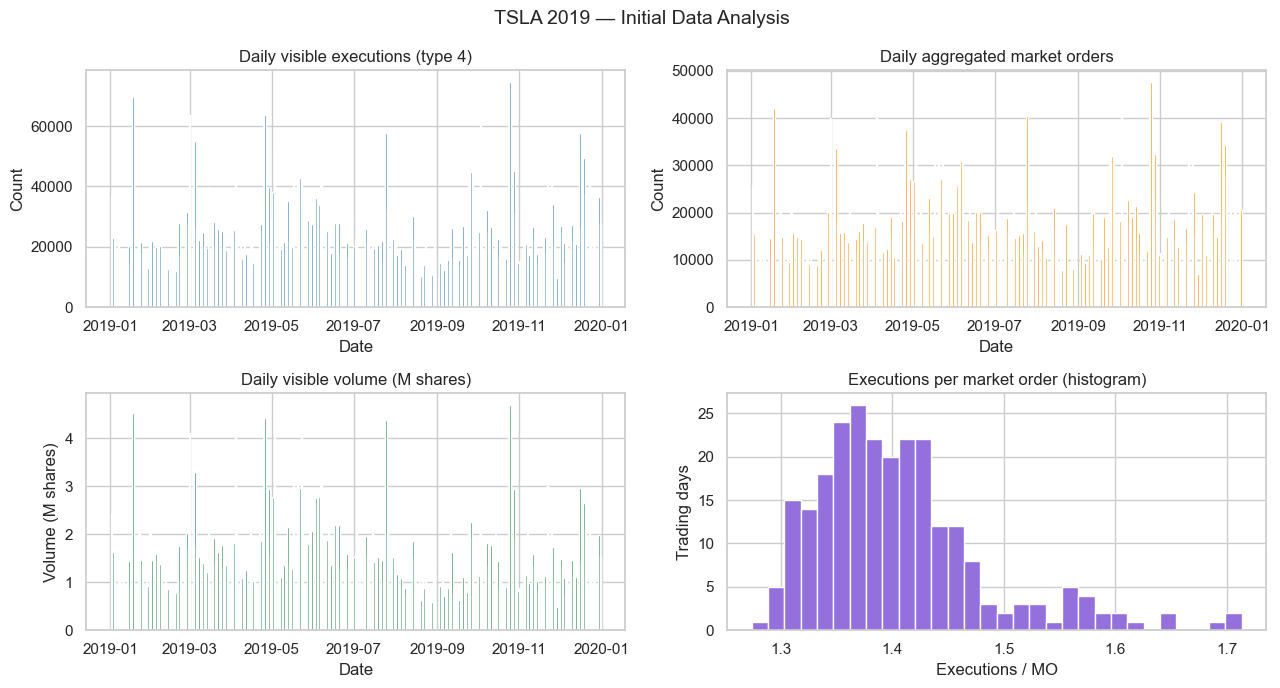

,Visible executions,Market orders,Visible volume (shares)
statistic,,,
count,252.0,252.0,252.0
mean,25809.7,18150.6,1655348.0
std,12161.6,7821.5,812439.2
min,576.0,405.0,30844.0
25%,17430.2,12813.2,1120000.5
50%,22610.0,16034.5,1462074.5
75%,29970.2,20995.8,1927565.8
max,74718.0,47701.0,4699501.0


In [54]:
# ── Daily-level statistics ─────────────────────────────────────────────────────
summary = pd.read_csv(prepared.daily_summary, parse_dates=["date"])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("TSLA 2019 — Initial Data Analysis", fontsize=14)

# 1. Daily visible-execution count
ax = axes[0, 0]
ax.bar(summary["date"], summary["visible_executions"], width=1, color="steelblue")
ax.set_title("Daily visible executions (type 4)")
ax.set_xlabel("Date"); ax.set_ylabel("Count")

# 2. Daily aggregated market-order count
ax = axes[0, 1]
ax.bar(summary["date"], summary["market_orders"], width=1, color="darkorange")
ax.set_title("Daily aggregated market orders")
ax.set_xlabel("Date"); ax.set_ylabel("Count")

# 3. Daily visible volume (shares)
ax = axes[1, 0]
ax.bar(summary["date"], summary["visible_volume"] / 1e6, width=1, color="seagreen")
ax.set_title("Daily visible volume (M shares)")
ax.set_xlabel("Date"); ax.set_ylabel("Volume (M shares)")

# 4. Average executions per market order
ratio = summary["visible_executions"] / summary["market_orders"].clip(lower=1)
ax = axes[1, 1]
ax.hist(ratio, bins=30, color="mediumpurple", edgecolor="white")
ax.set_title("Executions per market order (histogram)")
ax.set_xlabel("Executions / MO"); ax.set_ylabel("Trading days")

plt.tight_layout()
plt.show()

# Descriptive statistics table
desc = summary[["visible_executions", "market_orders", "visible_volume"]].describe().round(1)
desc.index.name = "statistic"
desc.columns = ["Visible executions", "Market orders", "Visible volume (shares)"]
display(desc)


### 1.2 Limit Order Book, Spread and Visible Depth

> The order-book reconstruction corresponding to the sticky-price analysis
> is reproduced in **Section 8.4 — Sticky Price and Visible Depth**.

Executions sharing the exact same timestamp and initiating sign are grouped
together: a market order may consume several resting limit orders.  Timestamp
aggregation follows the transaction reconstruction used by Patzelt and Bouchaud
(2017) when exchange trade IDs are unavailable.  The analysis is intentionally
scoped to visible LOBSTER type-4 executions because this is the scope used by
the course notebook. Hidden executions are intentionally out of scope.


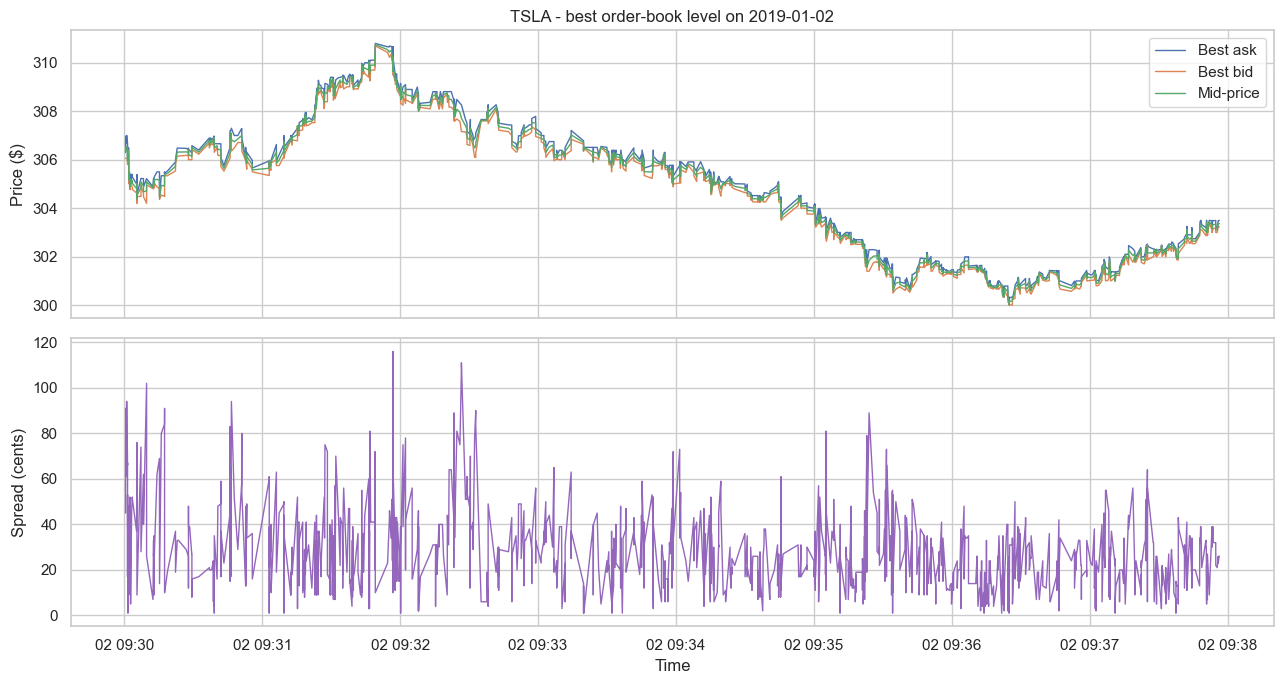

In [55]:
sample_date = summary.loc[0, "date"].strftime("%Y-%m-%d")
sample = trades[trades["date"].eq(sample_date)].head(2_000)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(sample["timestamp"], sample["ask_price_1_before"], label="Best ask", lw=1)
axes[0].plot(sample["timestamp"], sample["bid_price_1_before"], label="Best bid", lw=1)
axes[0].plot(sample["timestamp"], sample["mid_price_before"], label="Mid-price", lw=1)
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"{SYMBOL} - best order-book level on {sample_date}")
axes[0].legend()
axes[1].plot(sample["timestamp"], sample["spread_before"] * 100, color="tab:purple", lw=1)
axes[1].set_ylabel("Spread (cents)")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

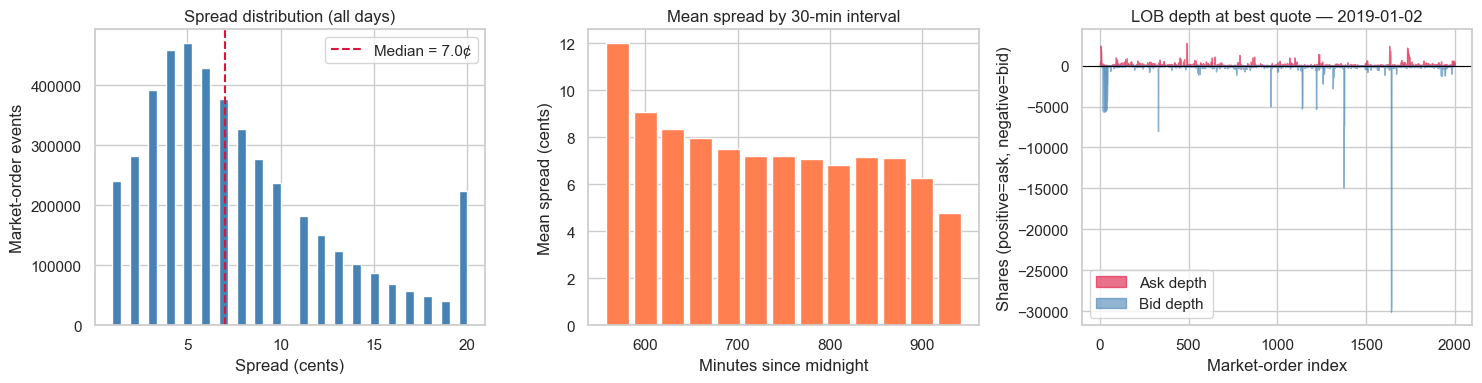

,TSLA 2019
Mean spread (cents),8.016
Median spread (cents),7.000
Std spread (cents),6.147
Fraction at 1-tick spread,0.053
Fraction at 2-tick spread,0.062


In [56]:
# ── LOB depth snapshot and spread statistics ───────────────────────────────────
sample_date = summary.loc[0, "date"].strftime("%Y-%m-%d")
sample = trades[trades["date"].eq(sample_date)].copy()

# --- Spread distribution across all 252 days ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
spread_cents = trades["spread_before"] * 100
ax.hist(spread_cents.clip(0, 20), bins=40, color="steelblue", edgecolor="white")
ax.set_title("Spread distribution (all days)")
ax.set_xlabel("Spread (cents)")
ax.set_ylabel("Market-order events")
ax.axvline(spread_cents.median(), color="crimson", ls="--", label=f"Median = {spread_cents.median():.1f}¢")
ax.legend()

# --- Average spread by half-hour intraday (U-shape) ---
ax = axes[1]
if "timestamp" in trades.columns:
    intraday = trades.copy()
    # seconds is time since midnight (LOBSTER convention)
    intraday["minute"] = (intraday["seconds"] // 60).astype(int)
    intraday["half_hour"] = (intraday["minute"] // 30) * 30
    intraday_spread = intraday.groupby("half_hour")["spread_before"].mean() * 100
    ax.bar(intraday_spread.index, intraday_spread.values, width=25, color="coral")
    ax.set_title("Mean spread by 30-min interval")
    ax.set_xlabel("Minutes since midnight")
    ax.set_ylabel("Mean spread (cents)")
else:
    ax.text(0.5, 0.5, "timestamp not available", ha="center", va="center")

# --- LOB depth (ask_size + bid_size) at level 1 for sample day ---
ax = axes[2]
sample2k = sample.head(2000)
ax.fill_between(range(len(sample2k)), sample2k["ask_size_1_before"],
                label="Ask depth", alpha=0.6, color="crimson")
ax.fill_between(range(len(sample2k)), -sample2k["bid_size_1_before"],
                label="Bid depth", alpha=0.6, color="steelblue")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"LOB depth at best quote — {sample_date}")
ax.set_xlabel("Market-order index")
ax.set_ylabel("Shares (positive=ask, negative=bid)")
ax.legend()

plt.tight_layout()
plt.show()

spread_stats = pd.Series({
    "Mean spread (cents)": spread_cents.mean(),
    "Median spread (cents)": spread_cents.median(),
    "Std spread (cents)": spread_cents.std(),
    "Fraction at 1-tick spread": (spread_cents < 1.5).mean(),
    "Fraction at 2-tick spread": ((spread_cents >= 1.5) & (spread_cents < 2.5)).mean(),
}, name="TSLA 2019")
display(spread_stats.round(3).to_frame())

## 2. Returns and Stylised Facts - Tuesday

### 2.1 Event-time Returns and Aggregate Gaussianity

The **event-time log return** over a horizon $\ell$ market orders is:

$$
r_t(\ell) = \log m_{t+\ell} - \log m_t.
$$

Two canonical stylised facts *(Cont 2001; Bouchaud et al. 2003)*:

1. **Heavy tails / non-Gaussianity at high frequency.** The distribution of
   $r_t(1)$ has excess kurtosis. As $\ell$ increases the distribution converges
   toward a Gaussian: this is aggregate Gaussianity.

2. **Long-range correlations.** Market-order signs are positively
   auto-correlated over many events. Return magnitudes are also positively
   auto-correlated, which is the volatility-clustering effect.

We illustrate both on the first 20 trading days for a fast exploratory view.
The article-replication section below uses the full filtered annual sample.


In [57]:

def _trade_sort_columns(data: pd.DataFrame, include_date: bool = True) -> list[str]:
    """Return sort key for deterministic event ordering within a day."""
    columns = ["date"] if include_date else []
    if "first_event_row" in data.columns:
        return columns + ["first_event_row"]
    return columns + ["seconds", "trade_sign"]


IMPACT_MID_PRICE_COLUMN = "mid_price_before"
IMPACT_SPREAD_COLUMN = "spread_before"
TEACHER_MID_PRICE_COLUMN = "mid_price_after"
TEACHER_SPREAD_COLUMN = "spread_after"


def add_lag1_features(market_orders: pd.DataFrame) -> pd.DataFrame:
    """Add one-trade-ahead pre-trade-mid impact and daily normalisation columns."""
    trades = market_orders.sort_values(_trade_sort_columns(market_orders)).copy()
    by_day = trades.groupby("date", sort=True, observed=True)
    trades["next_mid_price"] = by_day[IMPACT_MID_PRICE_COLUMN].shift(-1)
    trades["lag1_mid_change"] = trades["next_mid_price"] - trades[IMPACT_MID_PRICE_COLUMN]
    trades["lag1_signed_impact"] = trades["trade_sign"] * trades["lag1_mid_change"]
    trades["daily_volume"] = by_day["size"].transform("sum")
    trades["daily_r1"] = trades.groupby("date", observed=True)[
        "lag1_signed_impact"
    ].transform("mean")
    trades["average_same_side_queue"] = trades.groupby("date", observed=True)[
        "same_side_queue_before"
    ].transform("mean")
    trades["normalised_trade_volume"] = trades["size"] / trades["average_same_side_queue"]
    trades["normalised_lag1_impact"] = trades["lag1_signed_impact"] / trades["daily_r1"]
    return trades


def compute_event_time_returns(
    market_orders: pd.DataFrame, horizons: Sequence[int] = (1, 10, 100)
) -> pd.DataFrame:
    """Compute log returns at several market-order event-time horizons."""
    frames: list[pd.DataFrame] = []
    for horizon in horizons:
        for date, day in market_orders.groupby("date", sort=True, observed=True):
            ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
            mid = ordered[IMPACT_MID_PRICE_COLUMN]
            values = np.log(mid.shift(-horizon)) - np.log(mid)
            frames.append(pd.DataFrame({
                "date": date,
                "horizon": horizon,
                "log_return": values.dropna().to_numpy(),
            }))
    return pd.concat(frames, ignore_index=True)


def autocorrelation_at_lags_by_day(
    data: pd.DataFrame, value_column: str, lags: Sequence[int]
) -> pd.DataFrame:
    """Estimate selected autocorrelation lags without crossing daily boundaries."""
    clean = data[["date", value_column]].dropna()
    mean = clean[value_column].mean()
    variance = clean[value_column].var(ddof=0)
    grouped = [
        day[value_column].to_numpy(dtype=float)
        for _, day in clean.groupby("date", sort=True, observed=True)
    ]
    rows = []
    for lag in lags:
        products = [
            (values[:-lag] - mean) * (values[lag:] - mean)
            for values in grouped if len(values) > lag
        ]
        count = sum(len(values) for values in products)
        covariance = sum(values.sum() for values in products)
        rows.append({
            "lag": int(lag),
            "autocorrelation": covariance / count / variance if count and variance else np.nan,
            "count": count,
        })
    return pd.DataFrame(rows)


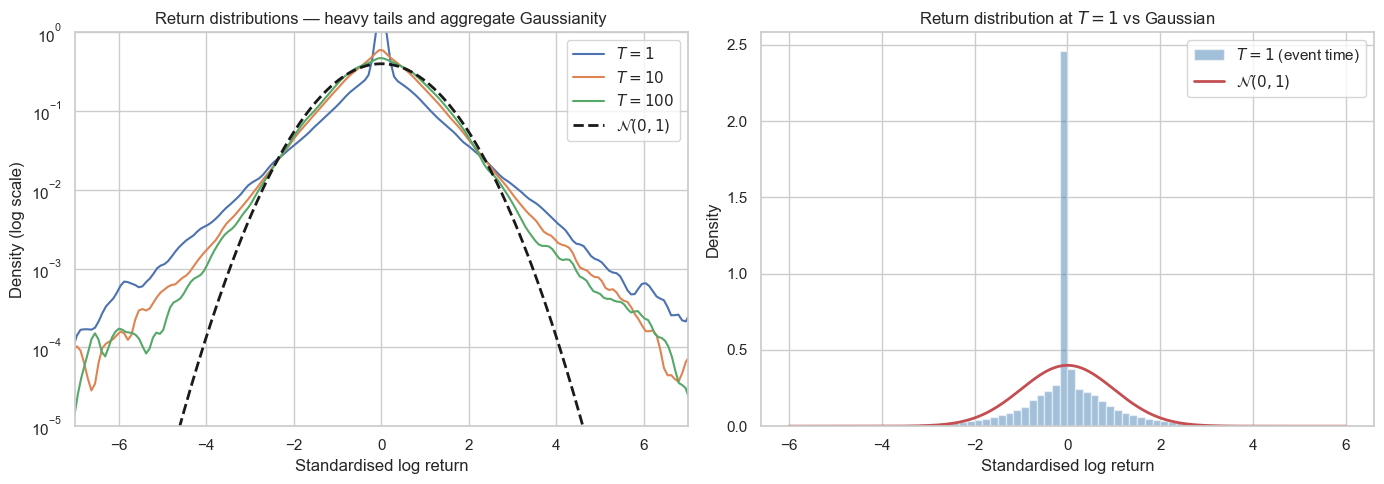

,N (returns),Skewness,Excess kurtosis,"KS stat vs N(0,1)",KS p-value
Horizon T,,,,,
1,316056,0.1399,9.8180,0.1858,0.0
10,315876,0.0983,3.1028,0.0482,0.0
100,314076,0.0406,1.7463,0.0225,0.0


In [58]:
exploratory_dates = sorted(trades["date"].unique())[:20]
exploratory = trades[trades["date"].isin(exploratory_dates)].copy()
exploratory_features = add_lag1_features(exploratory)
event_returns = compute_event_time_returns(exploratory, horizons=(1, 10, 100))
event_returns["standardised_return"] = event_returns.groupby("horizon")[
    "log_return"
].transform(lambda values: (values - values.mean()) / values.std())

# Gaussian reference grid
z = np.linspace(-6, 6, 300)
gaussian_pdf = np.exp(-0.5 * z ** 2) / np.sqrt(2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: KDE for each horizon on log-scale with Gaussian overlay ---
ax = axes[0]
for horizon, part in event_returns.groupby("horizon"):
    sns.kdeplot(
        part["standardised_return"].clip(-8, 8),
        ax=ax,
        label=f"$T={horizon}$",
        bw_adjust=1.2,
    )
ax.plot(z, gaussian_pdf, "k--", lw=2, label="$\\mathcal{N}(0,1)$")
ax.set_yscale("log")
ax.set_ylim(1e-5, 1)
ax.set_xlim(-7, 7)
ax.set_xlabel("Standardised log return")
ax.set_ylabel("Density (log scale)")
ax.set_title("Return distributions — heavy tails and aggregate Gaussianity")
ax.legend()

# --- Right: sample histogram for T=1 on linear scale with Gaussian ---
ax = axes[1]
r1_data = event_returns.loc[event_returns["horizon"].eq(1), "standardised_return"].clip(-5, 5)
ax.hist(r1_data, bins=60, density=True, alpha=0.5, color="steelblue", label="$T=1$ (event time)")
ax.plot(z, gaussian_pdf, "r-", lw=2, label="$\\mathcal{N}(0,1)$")
ax.set_xlabel("Standardised log return")
ax.set_ylabel("Density")
ax.set_title("Return distribution at $T=1$ vs Gaussian")
ax.legend()

plt.tight_layout()
plt.show()

# ── Kurtosis and skewness table ────────────────────────────────────────────────
from scipy.stats import kurtosis as _kurt, skew as _skew, kstest as _ks

rows = []
for horizon, part in event_returns.groupby("horizon"):
    std = part["standardised_return"]
    stat, pval = _ks(std, "norm")
    rows.append({
        "Horizon T": int(horizon),
        "N (returns)": len(std),
        "Skewness": _skew(std),
        "Excess kurtosis": _kurt(std),
        "KS stat vs N(0,1)": stat,
        "KS p-value": pval,
    })
display(pd.DataFrame(rows).set_index("Horizon T").round(4))

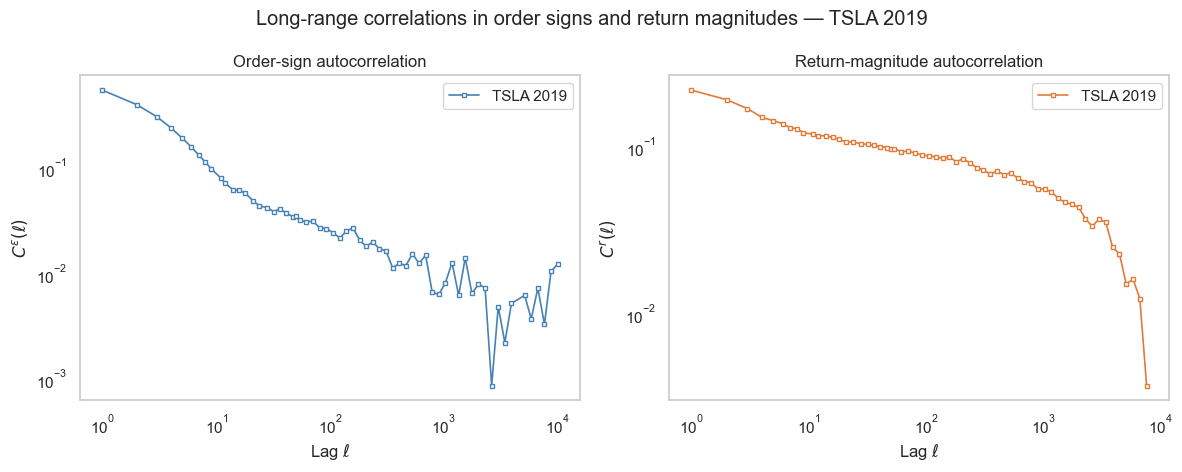

Sign ACF at lag 1:  0.5439
Sign ACF at lag 50: 0.0344
|Delta M| ACF at lag 1: 0.2180


In [59]:

# ── Long-range sign and return-magnitude autocorrelations ─────────────────────
exploratory_features["absolute_lag1_change"] = exploratory_features[
    "lag1_mid_change"
].abs()
maximum_lag = min(10_000, int(exploratory.groupby("date").size().max() // 2))
acf_lags = np.unique(np.r_[np.geomspace(1, maximum_lag, 70).astype(int), 50])
sign_acf = autocorrelation_at_lags_by_day(exploratory, "trade_sign", acf_lags)
absolute_return_acf = autocorrelation_at_lags_by_day(
    exploratory_features, "absolute_lag1_change", acf_lags
)

_acf_series = [
    (sign_acf,          "steelblue",  "$C^{\\varepsilon}(\\ell)$", "Order-sign autocorrelation"),
    (absolute_return_acf, "#e07b39",  "$C^{r}(\\ell)$",            "Return-magnitude autocorrelation"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (curve, color, ylabel, title) in zip(axes, _acf_series):
    positive = curve["autocorrelation"].gt(0)
    ax.loglog(
        curve.loc[positive, "lag"],
        curve.loc[positive, "autocorrelation"],
        marker="s", ms=3.2, mfc="white", mec=color,
        color=color, lw=1.2, label="TSLA 2019",
    )
    ax.set_xlabel("Lag $\\ell$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(False)
plt.suptitle("Long-range correlations in order signs and return magnitudes — TSLA 2019")
plt.tight_layout()
plt.show()

lag_50_sign = sign_acf.loc[sign_acf["lag"].eq(50), "autocorrelation"].iloc[0]
lag_1_abs = absolute_return_acf.loc[
    absolute_return_acf["lag"].eq(1), "autocorrelation"
].iloc[0]
print(f"Sign ACF at lag 1:  {sign_acf.loc[sign_acf['lag'].eq(1), 'autocorrelation'].iloc[0]:.4f}")
print(f"Sign ACF at lag 50: {lag_50_sign:.4f}")
print(f"|Delta M| ACF at lag 1: {lag_1_abs:.4f}")



### 2.2 Return-tail CCDF and Power-law Exponent

The log-scale density above reveals non-Gaussian returns. To isolate the tails,
we plot the complementary cumulative distribution function (CCDF) of absolute
standardised returns:

$$
P\left(\lvert r_t(\ell) \rvert \geq x\right).
$$

A Pareto tail $P(X \geq x) \propto x^{-\alpha}$ appears approximately linear
on log-log axes, with slope $-\alpha$. Following the power-law-tail discussion
in the lecture slides, the table estimates $\alpha$ by maximum likelihood above
the empirical 95th percentile $x_{\min}$ for each event-time horizon.


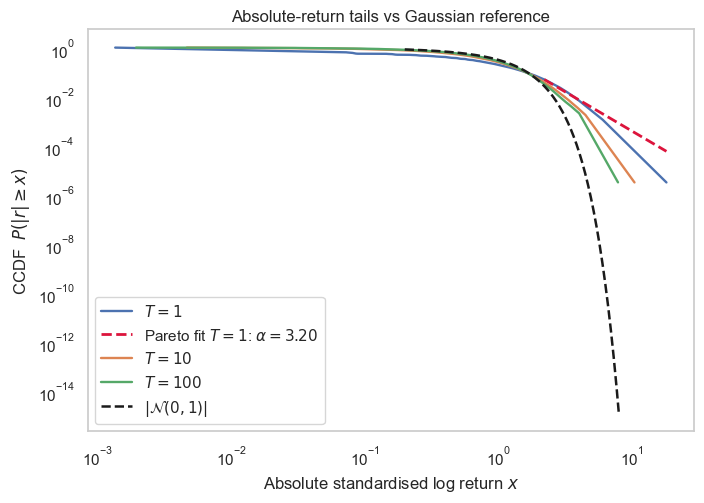

,Tail threshold quantile,x_min,N (tail returns),Tail probability,Pareto alpha (MLE),Alpha standard error
Horizon T,,,,,,
1,0.95,2.2130,15803,0.05,3.2031,0.0255
10,0.95,2.0495,15794,0.05,3.8605,0.0307
100,0.95,1.9781,15704,0.05,4.2489,0.0339


In [60]:

# ── Absolute-return CCDF and Pareto-tail estimates ────────────────────────────
from scipy.stats import norm as _norm

TAIL_QUANTILE = 0.95


def empirical_ccdf(values: pd.Series, max_points: int = 450) -> tuple[np.ndarray, np.ndarray]:
    """Return a downsampled CCDF while retaining zero returns in probabilities."""
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]
    positive = np.sort(array[array > 0])
    x, first_indices = np.unique(positive, return_index=True)
    y = (len(positive) - first_indices) / len(array)
    keep = np.unique(np.linspace(0, len(x) - 1, min(max_points, len(x))).astype(int))
    return x[keep], y[keep]


def fit_pareto_tail(values: pd.Series, quantile: float = TAIL_QUANTILE) -> dict[str, float]:
    """Fit P(X >= x) proportional to x**(-alpha) above an empirical threshold."""
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]
    threshold = float(np.quantile(array, quantile))
    tail = array[array >= threshold]
    log_excess = np.log(tail / threshold).sum()
    alpha = len(tail) / log_excess
    return {
        "Tail threshold quantile": quantile,
        "x_min": threshold,
        "N (tail returns)": len(tail),
        "Tail probability": len(tail) / len(array),
        "Pareto alpha (MLE)": alpha,
        "Alpha standard error": alpha / np.sqrt(len(tail)),
    }


fig, ax = plt.subplots(figsize=(7.2, 5.2))
tail_rows = []
tail_palette = dict(zip((1, 10, 100), sns.color_palette("deep", 3)))

for horizon, part in event_returns.groupby("horizon", sort=True):
    absolute_returns = part["standardised_return"].abs()
    x_ccdf, y_ccdf = empirical_ccdf(absolute_returns)
    fit = fit_pareto_tail(absolute_returns)
    fit["Horizon T"] = int(horizon)
    tail_rows.append(fit)
    ax.loglog(x_ccdf, y_ccdf, lw=1.7, color=tail_palette[horizon], label=f"$T={horizon}$")
    if horizon == 1:
        tail_grid = np.geomspace(fit["x_min"], x_ccdf.max(), 120)
        tail_fit = fit["Tail probability"] * (tail_grid / fit["x_min"]) ** (-fit["Pareto alpha (MLE)"])
        ax.loglog(tail_grid, tail_fit, color="crimson", ls="--", lw=2,
                  label=f"Pareto fit $T=1$: $\\alpha={fit['Pareto alpha (MLE)']:.2f}$")

gaussian_x = np.geomspace(0.20, 8, 300)
ax.loglog(gaussian_x, 2 * _norm.sf(gaussian_x), "k--", lw=1.8,
          label="$|\\mathcal{N}(0,1)|$")
ax.set_xlabel("Absolute standardised log return $x$")
ax.set_ylabel("CCDF  $P(|r| \\geq x)$")
ax.set_title("Absolute-return tails vs Gaussian reference")
ax.grid(False)
ax.legend()
plt.tight_layout()
plt.show()

tail_estimates = pd.DataFrame(tail_rows).set_index("Horizon T")
display(tail_estimates.round(4))



### 2.3 Returns at Nested Magnifications

Empirical TSLA log returns at successive zoom levels illustrate the clustered,
heavy-tailed nature of the series. The three-panel figure below applies three
zoom lengths (full sample, ×10, ×100).


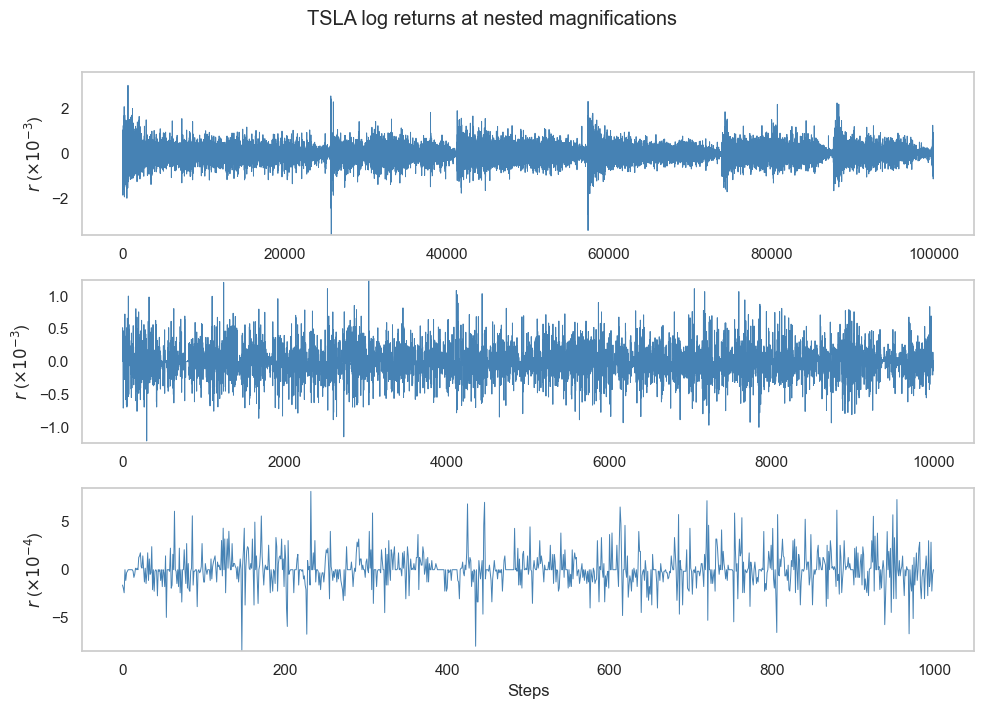

In [61]:

# ── TSLA returns at nested magnifications ────────────────────────────────────
tsla_zoom_returns = event_returns.loc[
    event_returns["horizon"].eq(1), "log_return"
].to_numpy()
n_zoom = min(100_000, len(tsla_zoom_returns))
tsla_zoom_returns = tsla_zoom_returns[:n_zoom]

fig, axes = plt.subplots(3, 1, figsize=(10, 7))
zoom_lengths = [n_zoom, min(10_000, n_zoom), min(1_000, n_zoom)]
for row, (ax, length) in enumerate(zip(axes, zoom_lengths)):
    start = max(0, (len(tsla_zoom_returns) - length) // 2)
    segment = tsla_zoom_returns[start:start + length]
    scale = np.max(np.abs(segment))
    unit_exponent = int(np.floor(np.log10(scale)))
    unit = 10.0 ** unit_exponent
    ax.plot(np.arange(length), segment / unit, color="steelblue", lw=0.7)
    ax.set_ylim(-scale / unit, scale / unit)
    ax.set_ylabel(f"$r$ ($\\times 10^{{{unit_exponent}}}$)")
    ax.grid(False)
axes[-1].set_xlabel("Steps")
plt.suptitle("TSLA log returns at nested magnifications", y=1.01)
plt.tight_layout()
plt.show()


## 3. Unconditional and Conditional Impact — Wednesday

### 3.1 Response Function $R(\ell)$

The **unconditional response function** (lecture slides, Fig 6) is:

$$
R(\ell) = \left\langle \varepsilon_t \left(m_{t+\ell} - m_t\right) \right\rangle.
$$

It measures how much the mid-price moves on average in the *same direction*
as a market order, $\ell$ trades later. Its value at $\ell = 1$:

$$
R(1) = \left\langle \varepsilon_t (m_{t+1} - m_t) \right\rangle
$$

is the **average lag-1 impact**, used throughout as the daily normalisation.
Daily boundaries are never crossed so that day-end effects do not contaminate
the estimate.

### 3.2 Lag-1 Conditional Impact $R(\upsilon, 1)$

The **lag-1 conditional impact** quantifies how impact depends on the
normalised market-order volume:

$$
R(\upsilon, 1) = \left\langle \varepsilon_t (m_{t+1} - m_t) \,\middle|\, \upsilon_t = \upsilon \right\rangle,
$$

where $\upsilon_t = v_t / \bar{q}_t$ is the ratio of the executed volume to
the average depth on the same side of the book on that day.

Empirically (lecture slides, Fig 7–8), this relationship is **sub-linear**:

$$
R(\upsilon, 1) \approx A \cdot \upsilon^{\,\zeta}, \qquad \zeta \ll 1.
$$

The concave curves in Fig 7 are for the large-tick stocks CSCO and INTC.
TSLA appears in Fig 8 as a small-tick stock: its dependence on volume is much
fainter and can be almost flat. The plot below therefore reports raw impact in
cents rather than forcing a vertical normalisation by daily $R(1)$.

In [62]:
def compute_response(market_orders: pd.DataFrame, max_lag: int = 50) -> pd.DataFrame:
    """Estimate pre-trade-mid unconditional response R(l) without crossing days."""
    totals = np.zeros(max_lag, dtype=float)
    counts = np.zeros(max_lag, dtype=np.int64)
    for _, day in market_orders.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered[IMPACT_MID_PRICE_COLUMN].to_numpy(dtype=float)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        for lag in range(1, min(max_lag, len(day) - 1) + 1):
            values = signs[:-lag] * (mid[lag:] - mid[:-lag])
            valid = np.isfinite(values)
            totals[lag - 1] += values[valid].sum()
            counts[lag - 1] += valid.sum()
    response = np.divide(totals, counts, out=np.full(max_lag, np.nan), where=counts > 0)
    return pd.DataFrame({"lag": np.arange(1, max_lag + 1), "response": response, "count": counts})


def compute_spread_normalised_r1(
    market_orders: pd.DataFrame,
    mid_column: str = TEACHER_MID_PRICE_COLUMN,
    spread_column: str = TEACHER_SPREAD_COLUMN,
) -> float:
    """Teacher-notebook convention: post-trade lag-1 impact over current spread."""
    values: list[np.ndarray] = []
    for _, day in market_orders.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        if len(ordered) < 2:
            continue
        mid = ordered[mid_column].to_numpy(dtype=float)
        spread = ordered[spread_column].to_numpy(dtype=float)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        impact = signs[:-1] * (mid[1:] - mid[:-1])
        scaled = impact / spread[:-1]
        values.append(scaled[np.isfinite(scaled)])
    return float(np.concatenate(values).mean())


def bin_conditional_impact(
    trades: pd.DataFrame,
    maximum_volume: float = 2.0,
    fine_threshold: float = 0.1,
    fine_step: float = 0.01,
    coarse_step: float = 0.1,
) -> pd.DataFrame:
    """Average raw lag-1 impact in regularised normalised-volume bins."""
    clean = trades.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["normalised_trade_volume", "lag1_signed_impact"]
    )
    fine_edges = np.arange(0.0, fine_threshold + fine_step / 2, fine_step)
    coarse_edges = np.arange(
        fine_threshold + coarse_step, maximum_volume + coarse_step / 2, coarse_step
    )
    labels = pd.cut(
        clean["normalised_trade_volume"],
        bins=np.r_[fine_edges, coarse_edges],
        include_lowest=True,
        right=False,
    )
    return (
        clean.assign(volume_bin=labels)
        .groupby("volume_bin", observed=True)
        .agg(
            normalised_trade_volume=("normalised_trade_volume", "mean"),
            lag1_signed_impact=("lag1_signed_impact", "mean"),
            observations=("lag1_signed_impact", "size"),
        )
        .reset_index(drop=True)
    )

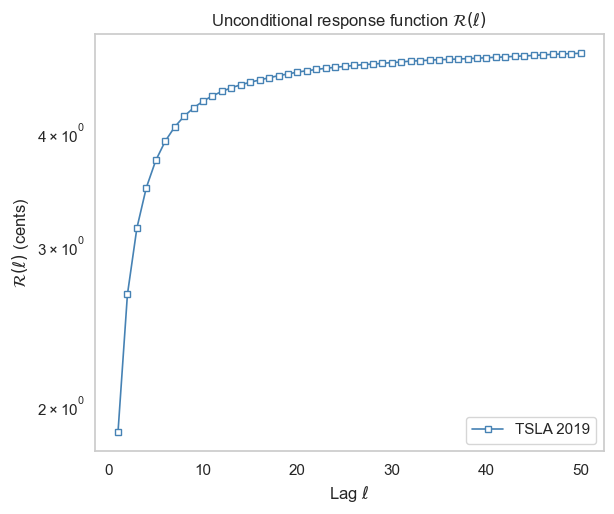

R(1) = 1.86981 cents  (0.018698 dollars)
Spread-normalised R1 = 0.14298


In [63]:

# ── Unconditional response function R(ℓ) ─────────────────────────────────────
response = compute_response(trades, max_lag=50)
r1 = response.loc[response["lag"].eq(1), "response"].iloc[0]
r1_spread_normalised = compute_spread_normalised_r1(trades)
positive_response = response["response"].clip(lower=np.finfo(float).tiny)

fig, ax = plt.subplots(figsize=(6.3, 5.3))
ax.semilogy(
    response["lag"], positive_response * 100,
    marker="s", ms=4, mfc="white", mec="steelblue", color="steelblue", lw=1.2,
    label="TSLA 2019",
)
ax.set_xlabel("Lag $\\ell$")
ax.set_ylabel("$\\mathcal{R}(\\ell)$ (cents)")
ax.set_title("Unconditional response function $\\mathcal{R}(\\ell)$")
ax.legend(loc="lower right", frameon=True)
ax.grid(False)
plt.tight_layout()
plt.show()

print(f"R(1) = {r1 * 100:.5f} cents  ({r1:.6f} dollars)")
print(f"Spread-normalised R1 = {r1_spread_normalised:.5f}")


In [64]:
features = add_lag1_features(trades)
daily_r1 = (
    features.groupby("date", observed=True)
    .agg(
        daily_r1=("daily_r1", "first"),
        daily_volume=("daily_volume", "first"),
        trades=("size", "size"),
    )
    .reset_index()
)
positive_daily_r1 = daily_r1.loc[daily_r1["daily_r1"] > 0, "daily_r1"]
r1_floor = positive_daily_r1.quantile(0.05)
stable_features = features[features["daily_r1"] >= r1_floor].copy()

display(daily_r1.describe())
print(
    "Stability filter for daily normalisations: "
    f"R(1) >= {r1_floor * 100:.6f} cents."
)

,daily_r1,daily_volume,trades
count,252.000000,2.520000e+02,252.000000
mean,0.019369,1.655348e+06,18150.623016
std,0.006318,8.124392e+05,7821.517064
min,0.010243,3.084400e+04,405.000000
25%,0.015432,1.120000e+06,12813.250000
50%,0.018458,1.462074e+06,16034.500000
75%,0.021168,1.927566e+06,20995.750000
max,0.080371,4.699501e+06,47701.000000


Stability filter for daily normalisations: R(1) >= 1.305750 cents.


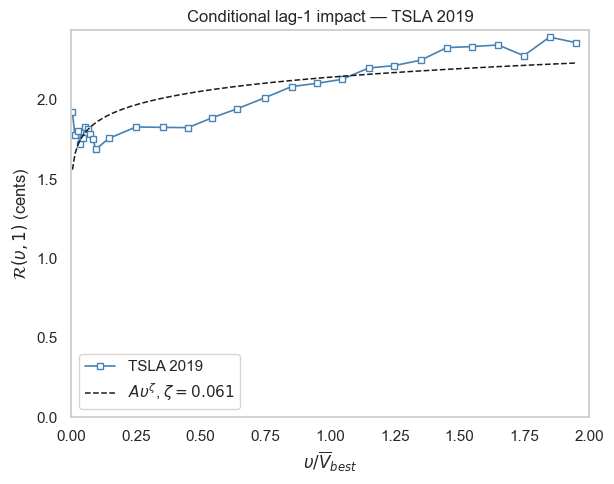

Power-law fit over 0 < υ / V_best < 2: A = 0.02142,  zeta = 0.0612


In [65]:
# ── Conditional lag-1 impact R(υ, 1) ─────────────────────────────────────────
# Normalise within each day before pooling so between-day volatility variation
# does not flatten the volume-impact curve.  Use stable_features (daily R(1) >=
# r1_floor) to exclude noisy low-impact days.
from scipy.optimize import curve_fit

_norm = stable_features.copy()
_norm["lag1_signed_impact"] = _norm["normalised_lag1_impact"]   # divide by daily R(1)
conditional_curve = bin_conditional_impact(_norm)
conditional_curve["lag1_signed_impact"] *= r1                   # scale back to price units

mask = (
    conditional_curve["normalised_trade_volume"].gt(0)
    & conditional_curve["lag1_signed_impact"].gt(0)
)
xdata = conditional_curve.loc[mask, "normalised_trade_volume"].to_numpy()
ydata = conditional_curve.loc[mask, "lag1_signed_impact"].to_numpy()

try:
    popt, _ = curve_fit(
        lambda x, A, zeta: A * np.power(x, zeta),
        xdata, ydata, p0=[0.02, 0.3], maxfev=10_000,
    )
    A_fit, zeta_fit = popt
    has_fit = True
except Exception:
    A_fit, zeta_fit, has_fit = np.nan, np.nan, False

fig, ax = plt.subplots(figsize=(6.3, 5.0))
ax.plot(
    conditional_curve["normalised_trade_volume"],
    conditional_curve["lag1_signed_impact"] * 100,
    marker="s", ms=4, mfc="white", mec="steelblue", color="steelblue", lw=1.2,
    label="TSLA 2019",
)
if has_fit:
    xgrid = np.linspace(max(xdata.min(), 1e-6), xdata.max(), 200)
    ax.plot(xgrid, A_fit * xgrid ** zeta_fit * 100, "k--", lw=1.1,
            label=f"$A\\upsilon^\\zeta$, $\\zeta={zeta_fit:.3f}$")
ax.set_xlim(0, 2)
ax.set_ylim(bottom=0)
ax.set_xlabel("$\\upsilon / \\overline{V}_{best}$")
ax.set_ylabel("$\\mathcal{R}(\\upsilon,1)$ (cents)")
ax.set_title("Conditional lag-1 impact — TSLA 2019")
ax.legend(loc="best")
ax.grid(False)
plt.tight_layout()
plt.show()

if has_fit:
    print(f"Power-law fit over 0 < υ / V_best < 2: A = {A_fit:.5f},  zeta = {zeta_fit:.4f}")


## 4. Aggregate Impact — Wednesday

### 4.1 Coarse-graining over $T$ consecutive market orders

Instead of looking trade by trade, we aggregate over windows of $T$ successive
market orders from the same day:

$$
\Delta\varepsilon(T) = \sum_{n=t}^{t+T-1} \varepsilon_n
\qquad (\text{order-sign imbalance}),
$$

$$
\Delta V(T) = \sum_{n=t}^{t+T-1} \varepsilon_n \, v_n
\qquad (\text{signed volume imbalance}),
$$

$$
R(\Delta V, T) = \left\langle m_{t+T} - m_t \,\middle|\, \Delta V \right\rangle.
$$

Non-overlapping windows (`stride = horizon`) are used to preserve independence
across observations and keep the annual dataset tractable. We normalise:

$$
\widetilde{\Delta V} = \frac{\Delta V}{V_D}, \quad
\widetilde{R} = \frac{R(\Delta V, T)}{R(1)},
$$

where $V_D$ is the daily traded volume and $R(1)$ is the daily lag-1 impact.

### 4.2 Expected shape from Patzelt & Bouchaud (2017)

The aggregate impact curve $R(\Delta V, T)$ is *concave* for small $T$ and
becomes more *linear* for large $T$. This behaviour is captured by the
sigmoidal master curve (section 5). The raw scatter — before quantile binning
— shows that large $|\Delta V|$ values are not associated with large returns:
the price is **"pinned"** when order flow is extreme (liquidity games).

In [66]:
def compute_aggregate_windows(
    trades: pd.DataFrame,
    horizons: Sequence[int] = (5, 10, 20, 50, 100),
    stride: str | int = "horizon",
) -> pd.DataFrame:
    """Compute coarse-grained signed imbalances and impact within each day.

    Non-overlapping windows (stride == "horizon") match the coarse-graining
    operation from the lecture slides while keeping the annual dataset tractable.
    Pass stride=1 to enumerate every overlapping window.
    """
    frames: list[pd.DataFrame] = []
    for date, day in trades.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered[IMPACT_MID_PRICE_COLUMN].to_numpy(dtype=float)
        size = ordered["size"].to_numpy(dtype=float)
        sign = ordered["trade_sign"].to_numpy(dtype=float)
        signed_volume = size * sign
        daily_volume = size.sum()
        daily_r1 = ordered["lag1_signed_impact"].mean()
        if not np.isfinite(daily_r1) or daily_r1 <= 0 or daily_volume <= 0:
            continue
        sv_cs = np.r_[0.0, np.cumsum(signed_volume)]
        s_cs  = np.r_[0.0, np.cumsum(sign)]
        for horizon in horizons:
            step = horizon if stride == "horizon" else int(stride)
            starts = np.arange(0, len(ordered) - horizon, step)
            if not len(starts):
                continue
            stops = starts + horizon
            frames.append(pd.DataFrame({
                "date": date,
                "horizon": horizon,
                "volume_imbalance":           sv_cs[stops] - sv_cs[starts],
                "order_flow_imbalance":       s_cs[stops]  - s_cs[starts],
                "impact":                     mid[stops]   - mid[starts],
                "daily_volume":               daily_volume,
                "daily_r1":                   daily_r1,
                "normalised_volume_imbalance":(sv_cs[stops] - sv_cs[starts]) / daily_volume,
                "normalised_impact":          (mid[stops]   - mid[starts])   / daily_r1,
            }))
    return pd.concat(frames, ignore_index=True)


def quantile_impact_curve(windows: pd.DataFrame, quantiles: int = 31) -> pd.DataFrame:
    """Denoise aggregate impact with separate imbalance quantiles for each T."""
    frames: list[pd.DataFrame] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        labels = pd.qcut(part["normalised_volume_imbalance"], q=quantiles, duplicates="drop")
        curve = (
            part.assign(imbalance_bin=labels)
            .groupby("imbalance_bin", observed=True)
            .agg(
                normalised_volume_imbalance=("normalised_volume_imbalance", "mean"),
                normalised_impact=("normalised_impact", "mean"),
                impact=("impact", "mean"),
                volume_imbalance=("volume_imbalance", "mean"),
                observations=("normalised_impact", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)

In [67]:
HORIZONS = (5, 10, 20, 50, 100)
windows = compute_aggregate_windows(
    stable_features,
    horizons=HORIZONS,
    stride="horizon",
)
impact_curve = quantile_impact_curve(windows, quantiles=31)

display(windows.groupby("horizon").size().rename("windows").to_frame())

,windows
horizon,
5,846449
10,423165
20,211530
50,84543
100,42212


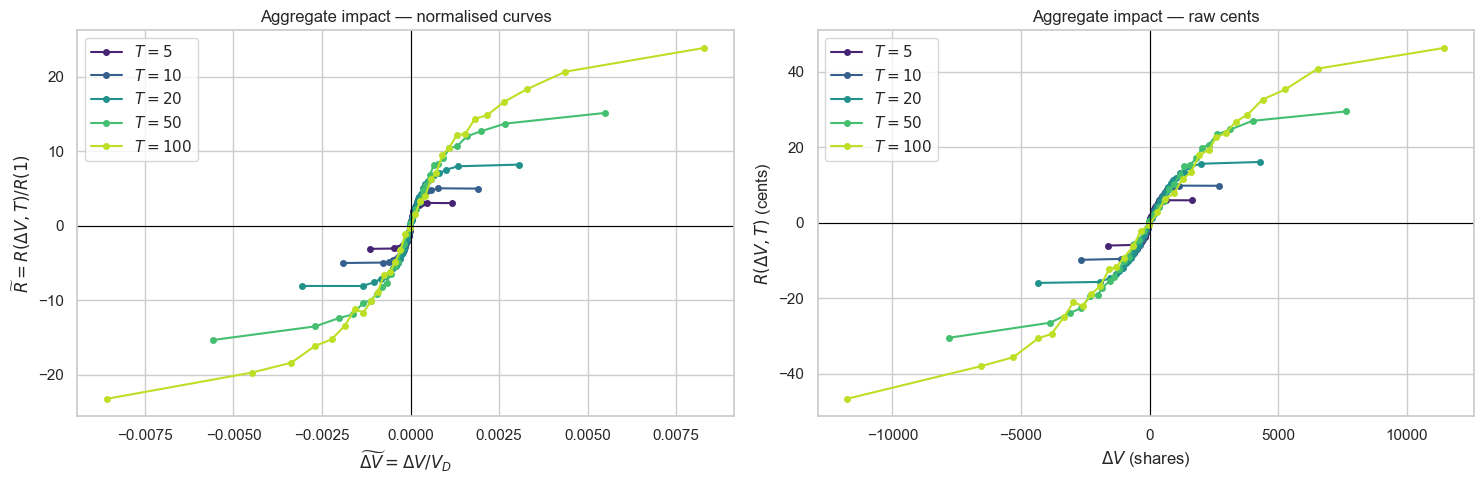

In [68]:
# ── Aggregate impact curves for each horizon T ────────────────────────────────
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: normalised impact curves ---
ax = axes[0]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(
        part["normalised_volume_imbalance"],
        part["normalised_impact"],
        marker="o", ms=4, color=color, label=f"$T={horizon}$",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\widetilde{\\Delta V} = \\Delta V / V_D$")
ax.set_ylabel("$\\widetilde{R} = R(\\Delta V, T) / R(1)$")
ax.set_title("Aggregate impact — normalised curves")
ax.legend(loc="upper left")

# --- Right: raw (un-normalised) impact curves ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(
        part["volume_imbalance"],
        part["impact"] * 100,
        marker="o", ms=4, color=color, label=f"$T={horizon}$",
    )
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\Delta V$ (shares)")
ax.set_ylabel("$R(\\Delta V, T)$ (cents)")
ax.set_title("Aggregate impact — raw cents")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

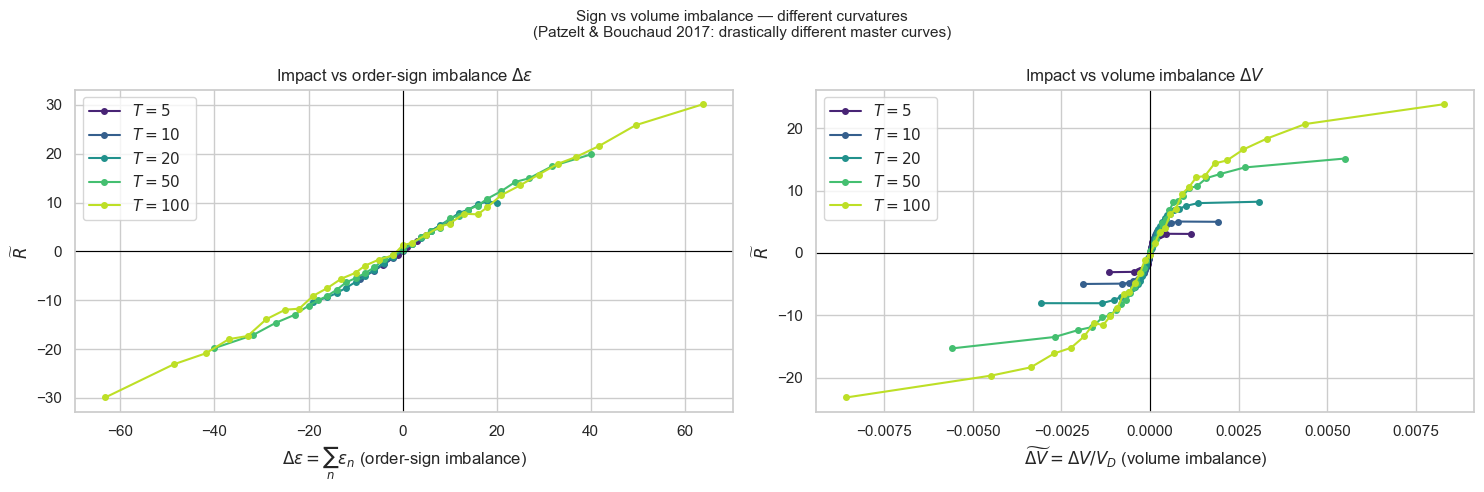

In [69]:
# ── Order-sign imbalance Δε vs volume imbalance ΔV ────────────────────────────
# Patzelt & Bouchaud (2017) show that sign impact and volume impact have
# drastically different master curves.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Impact vs ORDER-SIGN imbalance Δε ---
ax = axes[0]
sign_curve_parts = []
for horizon, part in windows.groupby("horizon", sort=True, observed=True):
    labels = pd.qcut(part["order_flow_imbalance"], q=31, duplicates="drop")
    sc = (
        part.assign(ofi_bin=labels)
        .groupby("ofi_bin", observed=True)
        .agg(
            order_flow_imbalance=("order_flow_imbalance", "mean"),
            normalised_impact=("normalised_impact", "mean"),
        )
        .reset_index(drop=True)
    )
    sc.insert(0, "horizon", horizon)
    sign_curve_parts.append(sc)
sign_impact_curve = pd.concat(sign_curve_parts, ignore_index=True)

for (horizon, part), color in zip(sign_impact_curve.groupby("horizon"), palette):
    ax.plot(part["order_flow_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\Delta\\varepsilon = \\sum_n \\varepsilon_n$ (order-sign imbalance)")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Impact vs order-sign imbalance $\\Delta\\varepsilon$")
ax.legend()

# --- Impact vs VOLUME imbalance ΔV (same as before for comparison) ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(part["normalised_volume_imbalance"], part["normalised_impact"],
            marker="o", ms=4, color=color, label=f"$T={horizon}$")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("$\\widetilde{\\Delta V} = \\Delta V / V_D$ (volume imbalance)")
ax.set_ylabel("$\\widetilde{R}$")
ax.set_title("Impact vs volume imbalance $\\Delta V$")
ax.legend()

plt.suptitle(
    "Sign vs volume imbalance — different curvatures\n"
    "(Patzelt & Bouchaud 2017: drastically different master curves)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 5. Finite-Size Scaling — Thursday

### 5.1 The Scaling Hypothesis

The key finding of Patzelt & Bouchaud (2017) is that for any intra-day
horizon $T$, the aggregate impact can be written in **scaling form**:

$$
R(\Delta V, T) \approx R(1)\, T^{\,\psi}\,
\mathcal{F}\!\left(\frac{\Delta V}{V_D \, T^{\xi}}\right),
$$

with the **sigmoidal master function**:

$$
\mathcal{F}(x) = \frac{x}{\bigl(1 + |x|^{\,\alpha}\bigr)^{\beta/\alpha}}.
$$

The exponents have physical interpretations:
- $\xi$ controls how the characteristic volume imbalance scales with $T$
- $\psi$ controls the amplitude growth with $T$
- $\alpha, \beta$ set the shape of the sigmoid (concavity)
- **Kyle's lambda exponent**: $\lambda = \xi - \psi$

Two auxiliary scale parameters (`amplitude`, `x_scale`) absorb unit
differences between the TSLA dataset and the normalisation convention.

### 5.2 Fitting Procedure

We fit all five curves simultaneously using nonlinear least squares
(`scipy.optimize.least_squares` with `soft_l1` loss for outlier robustness),
weighting each quantile bin by $\sqrt{N_{\text{obs}}}$.

In [70]:
def master_curve(x: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    """Sigmoidal scaling function F(x) = x / (1 + |x|^α)^(β/α)."""
    return x / np.power(1 + np.power(np.abs(x), alpha), beta / alpha)


def fit_finite_size_scaling(curve: pd.DataFrame) -> dict[str, float]:
    """Fit exponents and nuisance scales for a finite-size scaling collapse."""
    x       = curve["normalised_volume_imbalance"].to_numpy(dtype=float)
    y       = curve["normalised_impact"].to_numpy(dtype=float)
    horizon = curve["horizon"].to_numpy(dtype=float)
    weights = np.sqrt(curve["observations"].to_numpy(dtype=float))
    weights /= weights.max()

    def prediction(p: np.ndarray) -> np.ndarray:
        amplitude, x_scale, xi, psi, alpha, beta = p
        return amplitude * np.power(horizon, psi) * master_curve(
            x * np.power(horizon, -xi) / x_scale, alpha, beta
        )

    result = least_squares(
        lambda p: weights * (prediction(p) - y),
        x0=np.array([1.0, 0.001, 0.5, 0.3, 1.5, 0.5]),
        bounds=(
            np.array([1e-6, 1e-7, -1.0, -1.0, 0.1, 0.01]),
            np.array([1e4,  1.0,   2.0,  2.0,  8.0,  4.0]),
        ),
        loss="soft_l1",
        max_nfev=20_000,
    )
    amplitude, x_scale, xi, psi, alpha, beta = result.x
    return {
        "amplitude": float(amplitude), "x_scale": float(x_scale),
        "xi": float(xi),              "psi": float(psi),
        "alpha": float(alpha),        "beta": float(beta),
        "lambda_exponent": float(xi - psi),
        "cost": float(result.cost),   "success": bool(result.success),
    }


def renormalise_curve(curve: pd.DataFrame, parameters: dict[str, float]) -> pd.DataFrame:
    """Apply the fitted finite-size scaling transformation."""
    result = curve.copy()
    result["master_x"] = (
        result["normalised_volume_imbalance"]
        * np.power(result["horizon"], -parameters["xi"])
        / parameters["x_scale"]
    )
    result["master_y"] = (
        result["normalised_impact"]
        / parameters["amplitude"]
        / np.power(result["horizon"], parameters["psi"])
    )
    return result

In [71]:
fss_parameters = fit_finite_size_scaling(impact_curve)
fss_series = pd.Series(fss_parameters, name="TSLA 2019")
fss_series.index = [
    "amplitude $A$",
    "x-scale $x_0$",
    "volume exponent $\\xi$",
    "impact exponent $\\psi$",
    "sigmoid shape $\\alpha$",
    "sigmoid shape $\\beta$",
    "Kyle exponent $\\lambda = \\xi - \\psi$",
    "fit cost",
    "success",
]
display(fss_series.to_frame().round(4))

xi = fss_parameters["xi"]
psi = fss_parameters["psi"]
alpha = fss_parameters["alpha"]
beta = fss_parameters["beta"]
print(f"\nKey exponents:  ξ = {xi:.4f},  ψ = {psi:.4f},  α = {alpha:.4f},  β = {beta:.4f}")
print(f"Kyle exponent:  λ = ξ − ψ = {xi - psi:.4f}")

,TSLA 2019
amplitude $A$,1.403239
x-scale $x_0$,0.00002
volume exponent $\xi$,1.081947
impact exponent $\psi$,0.685703
sigmoid shape $\alpha$,1.232702
sigmoid shape $\beta$,1.114598
Kyle exponent $\lambda = \xi - \psi$,0.396244
fit cost,0.670585
success,True



Key exponents:  ξ = 1.0819,  ψ = 0.6857,  α = 1.2327,  β = 1.1146
Kyle exponent:  λ = ξ − ψ = 0.3962


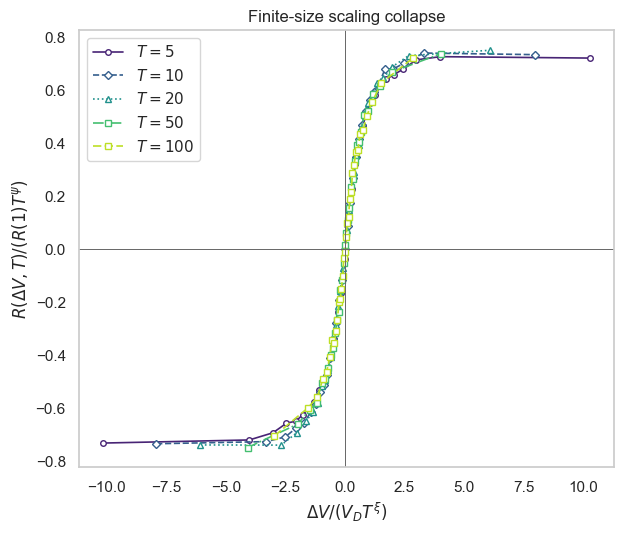

In [72]:

# ── Finite-size scaling collapse ──────────────────────────────────────────────
collapsed = renormalise_curve(impact_curve, fss_parameters)
palette_fss = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))
line_styles = ["-", "--", ":", "-.", (0, (5, 2))]
markers     = ["o", "D", "^", "s", "s"]

fig, ax = plt.subplots(figsize=(6.4, 5.5))
for (horizon, part), line_style, marker, color in zip(
    collapsed.groupby("horizon"), line_styles, markers, palette_fss
):
    ax.plot(
        part["master_x"], part["master_y"],
        linestyle=line_style, marker=marker, ms=4, mfc="white",
        color=color, lw=1.2, label=f"$T={horizon}$",
    )
ax.axhline(0, color="0.4", lw=0.7)
ax.axvline(0, color="0.4", lw=0.7)
ax.set_xlabel("$\\Delta V / (V_D T^\\xi)$")
ax.set_ylabel("$R(\\Delta V,T) / (R(1) T^\\psi)$")
ax.set_title("Finite-size scaling collapse")
ax.legend(loc="upper left", frameon=True)
ax.grid(False)
plt.tight_layout()
plt.show()


## 6. Kyle's Lambda — Thursday

### 6.1 Linear Regime and Market Illiquidity

In the limit of small $|\Delta V|$, the sigmoidal master curve is
approximately linear. The slope is **Kyle's lambda** $\lambda(T)$:

$$
\lambda(T) = \left.\frac{\partial R(\Delta V, T)}{\partial \Delta V}\right|_{\Delta V \approx 0}.
$$

In the scaling picture:

$$
\lambda(T) \propto T^{-\lambda}, \qquad \lambda = \xi - \psi.
$$

A large $\lambda$ means a given volume imbalance moves the price further —
the market is **less liquid**. As $T$ grows, the price impact per share falls
because the market has more time to absorb order flow.

We estimate $\lambda(T)$ by OLS on the central 35 % of the $|\Delta V|$
distribution (the approximately linear region), then fit the power law.

### 6.2 Connection to Kyle (1985) and Information Asymmetry

In Kyle's continuous-time model, the informed trader's profit is:

$$
\pi = \frac{1}{2\lambda}(\sigma_v)^2,
$$

where $\sigma_v$ is the information signal's standard deviation. A smaller
$\lambda$ (more liquid market) reduces informed profits. The empirical
decay $\lambda(T) \propto T^{-\lambda}$ shows that averaging over longer
windows reduces the effective information asymmetry per unit volume.

In [73]:
def estimate_kyle_lambdas(
    windows: pd.DataFrame, central_quantile: float = 0.35
) -> pd.DataFrame:
    """Estimate Kyle's lambda via OLS in the central (approximately linear) region."""
    rows: list[dict[str, float | int]] = []
    for horizon, part in windows.groupby("horizon", sort=True, observed=True):
        threshold = part["volume_imbalance"].abs().quantile(central_quantile)
        central = part[part["volume_imbalance"].abs() <= threshold]
        x = central["volume_imbalance"].to_numpy(dtype=float)
        y = central["impact"].to_numpy(dtype=float) * 100
        intercept, slope = np.linalg.lstsq(
            np.column_stack([np.ones(len(x)), x]), y, rcond=None
        )[0]
        rows.append({
            "horizon": int(horizon),
            "threshold_shares": float(threshold),
            "intercept_cents": float(intercept),
            "kyle_lambda_cents_per_share": float(slope),
            "observations": len(central),
        })
    return pd.DataFrame(rows)


def fit_kyle_decay(kyle_lambdas: pd.DataFrame) -> dict[str, float]:
    """Fit lambda(T) ∝ T^(-exponent) by log-log OLS."""
    clean = kyle_lambdas[kyle_lambdas["kyle_lambda_cents_per_share"] > 0]
    x = np.log(clean["horizon"].to_numpy(dtype=float))
    y = np.log(clean["kyle_lambda_cents_per_share"].to_numpy(dtype=float))
    intercept, slope = np.linalg.lstsq(
        np.column_stack([np.ones(len(x)), x]), y, rcond=None
    )[0]
    return {"prefactor": float(np.exp(intercept)), "lambda_exponent": float(-slope)}

In [74]:
kyle_lambdas = estimate_kyle_lambdas(windows, central_quantile=0.35)
kyle_decay = fit_kyle_decay(kyle_lambdas)

display(kyle_lambdas.set_index("horizon").round(5))
display(pd.Series(kyle_decay, name="Direct power-law fit").round(5).to_frame())
print(
    f"\nExponent predicted by FSS (ξ − ψ): {fss_parameters['lambda_exponent']:.5f}\n"
    f"Exponent from direct OLS fit:        {kyle_decay['lambda_exponent']:.5f}"
)

,threshold_shares,intercept_cents,kyle_lambda_cents_per_share,observations
horizon,,,,
5,172.0,0.05309,0.02420,296434
10,292.0,0.14987,0.01866,148553
20,473.0,0.31819,0.01487,74160
50,890.0,0.43627,0.01174,29607
100,1476.0,0.77345,0.00914,14775


,Direct power-law fit
prefactor,0.03938
lambda_exponent,0.31626



Exponent predicted by FSS (ξ − ψ): 0.39624
Exponent from direct OLS fit:        0.31626


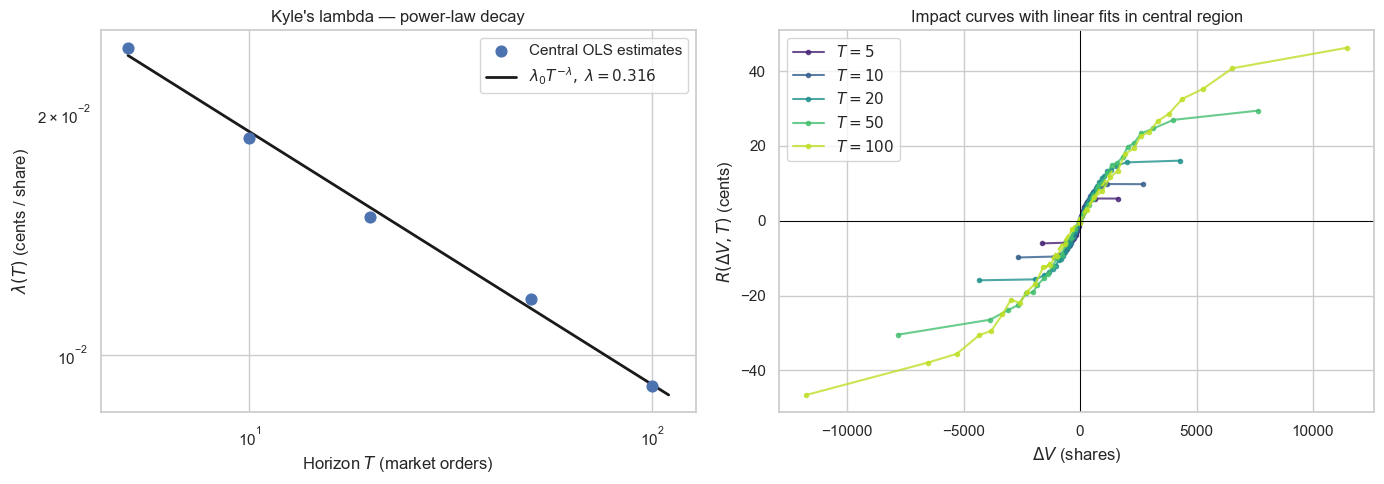

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizon_grid = np.geomspace(min(HORIZONS), max(HORIZONS) * 1.1, 200)
lambda_exp = kyle_decay["lambda_exponent"]
prefactor = kyle_decay["prefactor"]

# --- Left: log-log plot with power-law fit ---
ax = axes[0]
ax.scatter(kyle_lambdas["horizon"], kyle_lambdas["kyle_lambda_cents_per_share"],
           s=60, zorder=5, label="Central OLS estimates")
ax.plot(horizon_grid, prefactor * horizon_grid ** (-lambda_exp),
        "k-", lw=2, label=f"$\\lambda_0 T^{{-\\lambda}},\\;\\lambda={lambda_exp:.3f}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Horizon $T$ (market orders)")
ax.set_ylabel("$\\lambda(T)$ (cents / share)")
ax.set_title("Kyle's lambda — power-law decay")
ax.legend()

# --- Right: impact curve with linear fits overlaid ---
ax = axes[1]
for (horizon, part), color in zip(impact_curve.groupby("horizon"), palette):
    ax.plot(part["volume_imbalance"], part["impact"] * 100,
            marker="o", ms=3, color=color, alpha=0.8, label=f"$T={horizon}$")
    kl_row = kyle_lambdas[kyle_lambdas["horizon"].eq(horizon)]
    if len(kl_row):
        slope = kl_row["kyle_lambda_cents_per_share"].iloc[0]
        intercept = kl_row["intercept_cents"].iloc[0]
        threshold = kl_row["threshold_shares"].iloc[0]
        x_lin = np.linspace(-threshold, threshold, 100)
        ax.plot(x_lin, intercept + slope * x_lin, "--", color=color, lw=1.5)
ax.axhline(0, color="black", lw=0.7); ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("$\\Delta V$ (shares)")
ax.set_ylabel("$R(\\Delta V, T)$ (cents)")
ax.set_title("Impact curves with linear fits in central region")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 7. Bonus — Price-Change Probability and Pinned Prices

*(Patzelt & Bouchaud 2017, Section III.C)*

The quantity in Fig. 5 of Patzelt & Bouchaud is not the probability that an
entire $N$-trade window has a non-zero net return. It is a **trade-level**
price-change probability conditioned on the local order-sign bias.

We therefore use a causal lagged sign imbalance:

$$
\bar{\varepsilon}_{t,N}^{\mathrm{lag}}
= \frac{1}{N}\sum_{i=1}^{N}\varepsilon_{t-i},
$$

and estimate

$$
P\!\left(m^{\mathrm{after}}_t \neq m^{\mathrm{before}}_t
\,\middle|\, \bar{\varepsilon}_{t,N}^{\mathrm{lag}}\right).
$$

This uses the raw visible type-4 execution rows rather than timestamp-batched
market-order windows. Batching is appropriate for aggregate impact, but it is
too coarse here: asking whether a whole batch/window moved the mid-price makes
the probability mechanically close to one. The expected signature is a
*tent-shaped* curve: price changes are most likely near balanced recent order
flow and much less likely after strongly one-sided past flow.

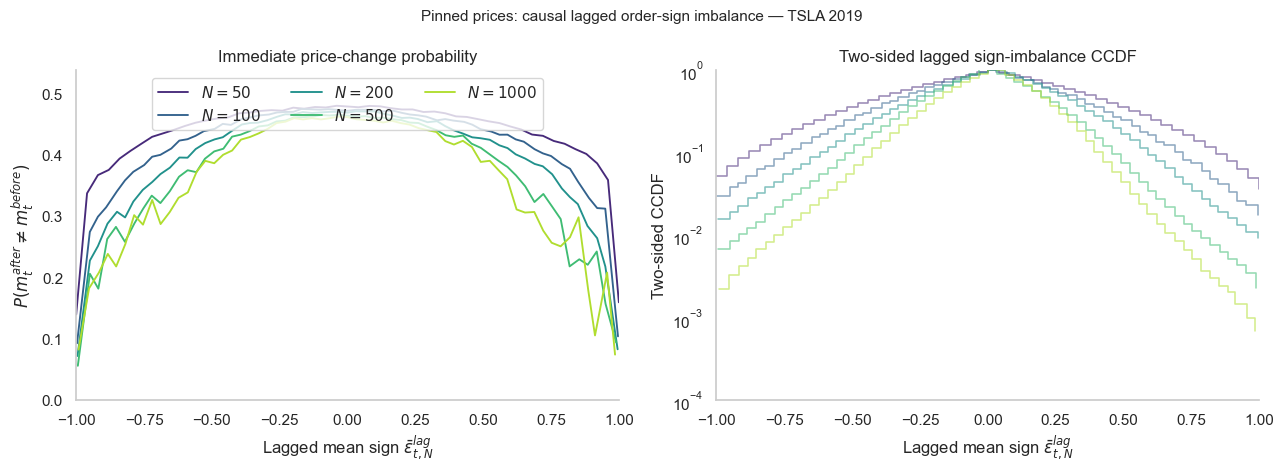

In [76]:
# ── Causal price-change probability from lagged order signs ───────────────────
# For each execution t and horizon N, condition the immediate mid-price change
# on the mean sign of the previous N visible type-4 executions.

PINNING_HORIZONS = (50, 100, 200, 500, 1_000)


def lagged_price_change_probability(
    executions: pd.DataFrame,
    horizons: Sequence[int],
    bins: int = 61,
) -> pd.DataFrame:
    """Estimate P(immediate mid change | mean sign over previous N executions)."""
    edges = np.linspace(-1.0, 1.0, bins + 1)
    frames: list[pd.DataFrame] = []
    for horizon in horizons:
        counts = np.zeros(bins, dtype=np.int64)
        changes = np.zeros(bins, dtype=float)
        mean_sums = np.zeros(bins, dtype=float)
        for _, day in executions.groupby("date", sort=True, observed=True):
            ordered = day.sort_values("event_row")
            if len(ordered) <= horizon:
                continue
            signs = ordered["trade_sign"].to_numpy(dtype=float)
            before = ordered["mid_price_before"].to_numpy(dtype=float)
            after = ordered["mid_price_after"].to_numpy(dtype=float)
            price_changed = (~np.isclose(after, before, rtol=0.0, atol=1e-12)).astype(float)
            sign_cs = np.r_[0.0, np.cumsum(signs)]

            # target t has N strictly past signs: eps[t-N], ..., eps[t-1]
            target = np.arange(horizon, len(ordered))
            mean_sign = (sign_cs[target] - sign_cs[target - horizon]) / horizon
            changed_at_target = price_changed[target]

            bin_index = np.searchsorted(edges, mean_sign, side="right") - 1
            bin_index = np.clip(bin_index, 0, bins - 1)
            counts += np.bincount(bin_index, minlength=bins)
            changes += np.bincount(bin_index, weights=changed_at_target, minlength=bins)
            mean_sums += np.bincount(bin_index, weights=mean_sign, minlength=bins)

        valid = counts > 0
        curve = pd.DataFrame({
            "horizon": horizon,
            "bin_left": edges[:-1][valid],
            "bin_right": edges[1:][valid],
            "mean_sign": mean_sums[valid] / counts[valid],
            "prob_change": changes[valid] / counts[valid],
            "observations": counts[valid],
        })
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


price_change_events = pd.read_parquet(
    prepared.visible_executions,
    columns=[
        "date", "seconds", "event_row", "trade_sign",
        "mid_price_before", "mid_price_after",
    ],
)
if USE_INTRADAY_TRADING_WINDOW:
    price_change_events = price_change_events.loc[
        price_change_events["seconds"].between(
            ANALYSIS_WINDOW_START_SECONDS,
            ANALYSIS_WINDOW_END_SECONDS,
            inclusive="both",
        )
    ]

pinning_curve = lagged_price_change_probability(
    price_change_events, PINNING_HORIZONS, bins=61
)
min_pinning_observations = 500
pinning_palette = plt.cm.viridis(np.linspace(0.12, 0.88, len(PINNING_HORIZONS)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for (horizon, part), color in zip(
    pinning_curve.groupby("horizon", sort=True), pinning_palette
):
    plot_part = part[part["observations"] >= min_pinning_observations]
    axes[0].plot(
        plot_part["mean_sign"], plot_part["prob_change"],
        color=color, lw=1.35, label=f"$N={horizon}$",
    )

    negative_tail = part[part["mean_sign"] <= 0].sort_values("mean_sign")
    positive_tail = part[part["mean_sign"] >= 0].sort_values("mean_sign")
    if len(negative_tail):
        negative_probability = (
            negative_tail["observations"].cumsum()
            / negative_tail["observations"].sum()
        )
        axes[1].step(
            negative_tail["mean_sign"], negative_probability,
            where="post", color=color, alpha=0.55, lw=1.15,
        )
    if len(positive_tail):
        positive_probability = (
            positive_tail["observations"][::-1].cumsum()[::-1]
            / positive_tail["observations"].sum()
        )
        axes[1].step(
            positive_tail["mean_sign"], positive_probability,
            where="post", color=color, alpha=0.55, lw=1.15,
        )

axes[0].set_xlim(-1, 1)
y_top = min(1.0, pinning_curve["prob_change"].max() * 1.12)
axes[0].set_ylim(0, y_top)
axes[0].set_xlabel(r"Lagged mean sign $\bar{\varepsilon}^{lag}_{t,N}$")
axes[0].set_ylabel(r"$P(m^{after}_t \neq m^{before}_t)$")
axes[0].set_title("Immediate price-change probability")
axes[0].legend(loc="upper center", ncol=3, frameon=True)
axes[0].grid(False)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_xlim(-1, 1)
axes[1].set_yscale("log")
axes[1].set_ylim(1e-4, 1)
axes[1].set_xlabel(r"Lagged mean sign $\bar{\varepsilon}^{lag}_{t,N}$")
axes[1].set_ylabel("Two-sided CCDF")
axes[1].set_title("Two-sided lagged sign-imbalance CCDF")
axes[1].grid(False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Pinned prices: causal lagged order-sign imbalance — TSLA 2019",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 8. Extended Analysis — Full Price Impact Scaling (Patzelt & Bouchaud 2017)

This section implements the methodology of *Universal scaling and nonlinearity
of aggregate price impact in financial markets* (Patzelt & Bouchaud 2017) on
the TSLA 2019 LOBSTER dataset.

Scope differences relative to the earlier sections are explicit:

- the available project dataset contains TSLA only, so the cross-instrument
  correlation panel (section 8.3) is not statistically estimable;
- sections 1-7 use visible LOBSTER type-4 executions; this extended PB section
  rebuilds transactions from both visible type-4 and hidden type-5 executions;
- because type-5 hidden executions do not consume displayed best-book depth,
  the PB trade sign is inferred from execution price relative to the pre-trade
  mid-price, and fills exactly at the mid-price are dropped as unsigned;
- the same global analysis window configured above is used, and aggregate
  returns are log returns.

In [77]:

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator


# ── Patzelt & Bouchaud (2017) extended-analysis constants ─────────────────────
PB_OPEN = ANALYSIS_WINDOW_START_SECONDS
PB_CLOSE = ANALYSIS_WINDOW_END_SECONDS
PB_CACHE_VERSION = "pb_transactions_type4_type5_inferred_sign_v1"
PB_HORIZONS = tuple(
    np.unique(np.rint(np.geomspace(10, 5_000, 28)).astype(int))
)


def _pb_cache_paths(processed_dir: Path, symbol: str, year: int) -> tuple[Path, Path]:
    transactions = processed_dir / f"{symbol}_{year}_pb_transactions.parquet"
    metadata = transactions.with_suffix(".metadata.json")
    return transactions, metadata


def _read_pb_transactions(day: DailyFiles) -> pd.DataFrame:
    """Build timestamp-merged transactions from visible and hidden fills.

    PB-style transaction reconstruction uses event types 4 and 5. The trade
    sign is inferred from execution price relative to the pre-trade mid-price,
    because hidden type-5 executions do not reliably reveal the aggressor side
    from displayed-book consumption.
    """
    messages = pd.read_csv(
        day.message_path, header=None,
        usecols=range(len(MESSAGE_COLUMNS)), names=MESSAGE_COLUMNS,
    )
    book_columns = orderbook_columns(day.levels)
    orderbook = pd.read_csv(day.orderbook_path, header=None, names=book_columns)
    if len(messages) != len(orderbook):
        raise ValueError(f"LOBSTER alignment failure for PB cache on {day.date}")
    event_rows = np.flatnonzero(messages["event_type"].isin([4, 5]).to_numpy())
    event_rows = event_rows[event_rows > 0]
    selected = messages.iloc[event_rows].reset_index(drop=True)
    before = orderbook.iloc[event_rows - 1].reset_index(drop=True)
    before.columns = [f"{column}_before" for column in before.columns]
    transactions = pd.concat([selected, before], axis=1)
    transactions.insert(0, "date", day.date)
    transactions.insert(1, "timestamp", _timestamps(day.date, transactions["seconds"]))
    transactions.insert(3, "first_event_row", event_rows)
    transactions["execution_price"] = transactions.pop("price_raw") / PRICE_SCALE
    price_columns = [
        column for column in transactions
        if "_price_" in column and column.endswith("_before")
    ]
    transactions[price_columns] = transactions[price_columns] / PRICE_SCALE
    transactions["mid_price_before"] = (
        transactions["ask_price_1_before"] + transactions["bid_price_1_before"]
    ) / 2
    transactions["trade_sign"] = np.sign(
        transactions["execution_price"] - transactions["mid_price_before"]
    ).astype(int)
    transactions = transactions[transactions["trade_sign"].ne(0)].copy()
    transactions["_weighted_notional"] = transactions["execution_price"] * transactions["size"]
    keys = ["date", "seconds", "trade_sign"]
    grouped = transactions.sort_values(["date", "first_event_row"]).groupby(
        keys, sort=True, observed=True
    )
    aggregations: dict[str, tuple[str, str]] = {
        "timestamp": ("timestamp", "first"),
        "first_event_row": ("first_event_row", "first"),
        "last_event_row": ("first_event_row", "last"),
        "transaction_count": ("event_type", "size"),
        "size": ("size", "sum"),
        "weighted_notional": ("_weighted_notional", "sum"),
        "mid_price_before": ("mid_price_before", "first"),
    }
    for column in transactions:
        if column.endswith("_before") and column != "mid_price_before":
            aggregations[column] = (column, "first")
    merged = grouped.agg(**aggregations).reset_index()
    merged["execution_price_vwap"] = merged.pop("weighted_notional") / merged["size"]
    return merged.sort_values(["date", "first_event_row"]).reset_index(drop=True)


In [78]:

def prepare_pb_transactions(
    raw_dir: Path | str,
    processed_dir: Path | str,
    symbol: str = "TSLA",
    year: int = 2019,
) -> Path:
    """Cache type-4/type-5 timestamp-merged transactions using the PB sign rule."""
    transactions_path, metadata_path = _pb_cache_paths(
        Path(processed_dir), symbol, year
    )
    if transactions_path.exists() and metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        if metadata.get("cache_version") == PB_CACHE_VERSION:
            return transactions_path
    temporary = transactions_path.with_suffix(".parquet.tmp")
    temporary.unlink(missing_ok=True)
    writer: pq.ParquetWriter | None = None
    pairs = [
        pair for pair in discover_daily_files(raw_dir, symbol=symbol)
        if pair.date.startswith(f"{year}-")
    ]
    try:
        for pair in pairs:
            writer = _append_parquet(writer, temporary, _read_pb_transactions(pair))
    finally:
        if writer is not None:
            writer.close()
    temporary.replace(transactions_path)
    metadata_path.write_text(
        json.dumps({"cache_version": PB_CACHE_VERSION}, indent=2) + "\n"
    )
    return transactions_path


def compute_pb_windows(
    market_orders: pd.DataFrame,
    horizons: Sequence[int],
) -> pd.DataFrame:
    """Build non-overlapping same-day windows with the Patzelt & Bouchaud definitions."""
    trimmed = market_orders[
        market_orders["seconds"].between(PB_OPEN, PB_CLOSE, inclusive="both")
    ].copy()
    daily_volume = trimmed.groupby("date", observed=True)["size"].sum()
    mean_daily_volume = daily_volume.mean()
    frames: list[pd.DataFrame] = []
    for date, day in trimmed.groupby("date", sort=True, observed=True):
        ordered = day.sort_values(_trade_sort_columns(day, include_date=False))
        mid = ordered["mid_price_before"].to_numpy(dtype=float)
        log_mid = np.log(mid)
        signs = ordered["trade_sign"].to_numpy(dtype=float)
        signed_volume = signs * ordered["size"].to_numpy(dtype=float)
        one_step_change = np.r_[np.diff(mid) != 0, False].astype(float)
        return_sign = np.r_[np.sign(np.diff(log_mid)), 0.0]
        q_cs = np.r_[0.0, np.cumsum(signed_volume)]
        e_cs = np.r_[0.0, np.cumsum(signs)]
        changed_cs = np.r_[0.0, np.cumsum(one_step_change)]
        return_sign_cs = np.r_[0.0, np.cumsum(return_sign)]
        volume_factor = mean_daily_volume / daily_volume.loc[date]
        for horizon in horizons:
            starts = np.arange(0, len(ordered) - horizon, horizon)
            if not len(starts):
                continue
            stops = starts + horizon
            frames.append(pd.DataFrame({
                "date": date,
                "horizon": horizon,
                "Q": volume_factor * (q_cs[stops] - q_cs[starts]),
                "E": e_cs[stops] - e_cs[starts],
                "mean_sign": (e_cs[stops] - e_cs[starts]) / horizon,
                "impact_log": log_mid[stops] - log_mid[starts],
                "price_change_probability": (
                    changed_cs[stops] - changed_cs[starts]
                ) / horizon,
                "return_sign_imbalance": (
                    return_sign_cs[stops] - return_sign_cs[starts]
                ),
            }))
    return pd.concat(frames, ignore_index=True)


In [79]:

def quantile_curve(
    data: pd.DataFrame, x_column: str, y_column: str, quantiles: int = 31
) -> pd.DataFrame:
    """Average a response in x-quantiles separately for every horizon."""
    frames: list[pd.DataFrame] = []
    for horizon, part in data.groupby("horizon", sort=True, observed=True):
        labels = pd.qcut(part[x_column], q=quantiles, duplicates="drop")
        curve = (
            part.assign(_bin=labels)
            .groupby("_bin", observed=True)
            .agg(
                x=(x_column, "mean"),
                y=(y_column, "mean"),
                observations=(y_column, "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


def fixed_sign_impact_curve(data: pd.DataFrame, bins: int = 61) -> pd.DataFrame:
    """Average sign-conditioned impact without hiding the extreme mean signs."""
    edges = np.linspace(-1, 1, bins + 1)
    frames: list[pd.DataFrame] = []
    for horizon, part in data.groupby("horizon", sort=True, observed=True):
        labels = pd.cut(part["mean_sign"], bins=edges, include_lowest=True)
        curve = (
            part.assign(_bin=labels)
            .groupby("_bin", observed=True)
            .agg(
                x=("E", "mean"),
                y=("impact_log", "mean"),
                observations=("impact_log", "size"),
            )
            .reset_index(drop=True)
        )
        curve.insert(0, "horizon", horizon)
        frames.append(curve)
    return pd.concat(frames, ignore_index=True)


In [80]:

def fit_volume_curve_scales(curve: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, float]]:
    """Fit Q_N, R_N and a common sigmoidal shape as in Patzelt & Bouchaud equations 3-6."""
    horizons = np.sort(curve["horizon"].unique())
    lookup = {horizon: index for index, horizon in enumerate(horizons)}
    horizon_index = curve["horizon"].map(lookup).to_numpy()
    x = curve["x"].to_numpy(dtype=float)
    y = curve["y"].to_numpy(dtype=float)
    weights = np.sqrt(curve["observations"].to_numpy(dtype=float))
    weights /= weights.max()
    grouped = curve.groupby("horizon", sort=True, observed=True)
    initial_q = grouped["x"].std().clip(lower=1e-9).to_numpy()
    initial_r = grouped["y"].std().clip(lower=1e-12).to_numpy()
    x0 = np.r_[np.log(initial_q), np.log(initial_r), np.log(1.2), np.log(1.3)]

    def unpack(parameters: np.ndarray) -> tuple[np.ndarray, np.ndarray, float, float]:
        count = len(horizons)
        q_scale = np.exp(parameters[:count])
        r_scale = np.exp(parameters[count:2 * count])
        alpha, beta = np.exp(parameters[-2:])
        return q_scale, r_scale, alpha, beta

    def residuals(parameters: np.ndarray) -> np.ndarray:
        q_scale, r_scale, alpha, beta = unpack(parameters)
        predicted = r_scale[horizon_index] * master_curve(
            x / q_scale[horizon_index], alpha, beta
        )
        return weights * (predicted - y)

    result = least_squares(
        residuals, x0=x0,
        bounds=(
            np.r_[np.full(len(horizons), -30.0), np.full(len(horizons), -30.0), np.log(0.1), np.log(0.1)],
            np.r_[np.full(len(horizons),  30.0), np.full(len(horizons),  5.0),  np.log(8.0), np.log(5.0)],
        ),
        loss="soft_l1", max_nfev=10_000,
    )
    q_scale, r_scale, alpha, beta = unpack(result.x)
    scales = pd.DataFrame({"horizon": horizons, "Q_N": q_scale, "R_N": r_scale})
    return scales, {
        "alpha": float(alpha), "beta": float(beta),
        "success": bool(result.success), "cost": float(result.cost),
    }


def fit_loglog_scale(x: pd.Series, y: pd.Series) -> dict[str, float]:
    """Fit y = prefactor * x**exponent and return the OLS standard error."""
    x_log = np.log(np.asarray(x, dtype=float))
    y_log = np.log(np.asarray(y, dtype=float))
    design = np.column_stack([np.ones(len(x_log)), x_log])
    intercept, exponent = np.linalg.lstsq(design, y_log, rcond=None)[0]
    residuals = y_log - design @ np.array([intercept, exponent])
    dof = max(1, len(x_log) - 2)
    covariance = np.linalg.inv(design.T @ design) * (residuals @ residuals) / dof
    return {
        "prefactor": float(np.exp(intercept)),
        "exponent": float(exponent),
        "stderr": float(np.sqrt(covariance[1, 1])),
    }


def sign_curve_scales(
    windows: pd.DataFrame, curve: pd.DataFrame
) -> tuple[pd.DataFrame, dict[str, float], dict[str, float]]:
    """Estimate sign-imbalance width and return height scales for collapse."""
    widths = windows.groupby("horizon", sort=True, observed=True)["E"].std()
    heights = curve.assign(abs_y=curve["y"].abs()).groupby(
        "horizon", sort=True, observed=True
    )["abs_y"].max()
    scales = pd.concat([widths.rename("E_N"), heights.rename("R_E_N")], axis=1).reset_index()
    return (
        scales,
        fit_loglog_scale(scales["horizon"], scales["E_N"]),
        fit_loglog_scale(scales["horizon"], scales["R_E_N"]),
    )


def ccdf_lines(
    values: pd.Series, scale: float, max_points: int = 220
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Return positive and negative half CCDF curves with bounded point count."""
    lines: list[tuple[np.ndarray, np.ndarray]] = []
    array = values.to_numpy(dtype=float) / scale
    for half in [array[array > 0], -array[array < 0]]:
        if not len(half):
            continue
        half = np.sort(half)
        keep = np.unique(np.linspace(0, len(half) - 1, min(max_points, len(half))).astype(int))
        x = half[keep]
        y = 1 - keep / len(half)
        lines.append((x, y))
    return lines


In [81]:

# ── Prepare extended type-4/type-5 dataset and compute all PB windows ────────
pb_transactions_path = prepare_pb_transactions(
    raw_working_copy, PROCESSED_DIR, symbol=SYMBOL, year=YEAR
)
pb_trades = pd.read_parquet(pb_transactions_path)
pb_trades = pb_trades.loc[
    pb_trades["seconds"].between(PB_OPEN, PB_CLOSE, inclusive="both")
].reset_index(drop=True)
pb_windows = compute_pb_windows(pb_trades, PB_HORIZONS)
pb_volume_curve = quantile_curve(pb_windows, "Q", "impact_log")
pb_sign_curve = fixed_sign_impact_curve(pb_windows)
pb_volume_scales, pb_shape = fit_volume_curve_scales(pb_volume_curve)
pb_sign_scales, pb_sign_x_fit, pb_sign_y_fit = sign_curve_scales(
    pb_windows, pb_sign_curve
)
pb_volume_x_fit = fit_loglog_scale(pb_volume_scales["horizon"], pb_volume_scales["Q_N"])
pb_volume_y_fit = fit_loglog_scale(pb_volume_scales["horizon"], pb_volume_scales["R_N"])

display(pd.Series({
    "regular intraday windows": len(pb_windows),
    "timestamp-aggregated PB transactions": len(pb_trades),
    "first included time": ANALYSIS_WINDOW_START,
    "last included time": ANALYSIS_WINDOW_END,
    "event types included": "4 + 5",
    "PB sign rule": "sign(execution price - pre-trade mid)",
    "unsigned midpoint fills dropped": True,
    "underlying signed fills": int(pb_trades["transaction_count"].sum()),
    "PB horizons": len(PB_HORIZONS),
}).to_frame("TSLA 2019 — extended analysis"))
display(pd.Series({
    "xi": pb_volume_x_fit["exponent"],
    "psi": pb_volume_y_fit["exponent"],
    "xi_epsilon": pb_sign_x_fit["exponent"],
    "psi_epsilon": pb_sign_y_fit["exponent"],
    "alpha": pb_shape["alpha"],
    "beta": pb_shape["beta"],
}).round(4).to_frame("estimate"))


,TSLA 2019 — extended analysis
regular intraday windows,2830851
timestamp-aggregated PB transactions,5879277
first included time,09:30:00
last included time,16:00:00
event types included,4 + 5
PB sign rule,sign(execution price - pre-trade mid)
unsigned midpoint fills dropped,True
underlying signed fills,8591382
PB horizons,28


,estimate
xi,0.9763
psi,0.6564
xi_epsilon,0.6933
psi_epsilon,0.7024
alpha,0.6756
beta,2.0346



### 8.1 Universal Collapse and CCDFs

The four panels, translucent horizon overlays and logarithmic `viridis`
colorbar follow the PB (2017) layout. The left column conditions on signed
volume imbalance $Q$; the right column conditions on sign imbalance $E$.


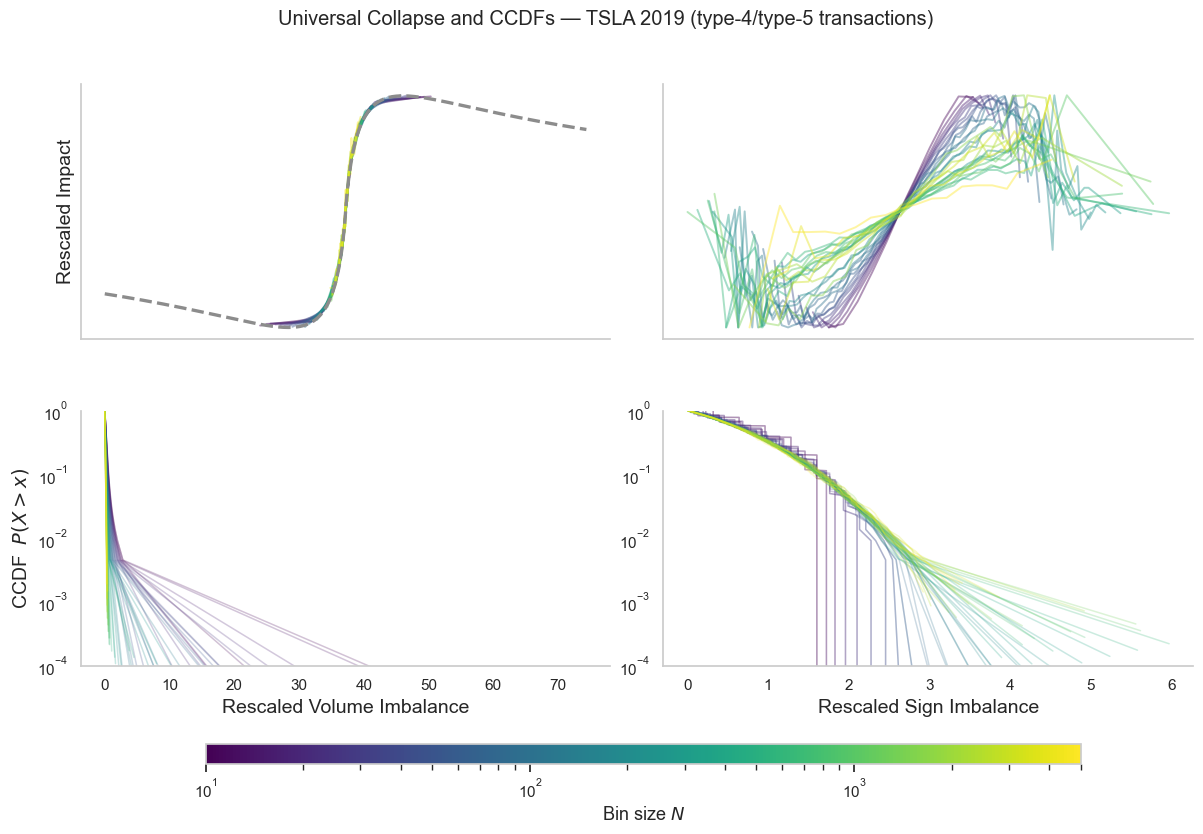

In [82]:

# ── Universal collapse and CCDFs ───────────────────────────────────────────────
volume_scale_lookup = pb_volume_scales.set_index("horizon")
sign_scale_lookup = pb_sign_scales.set_index("horizon")
color_norm = LogNorm(min(PB_HORIZONS), max(PB_HORIZONS))
cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2))
fig.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.19, hspace=0.28, wspace=0.10)

for horizon, part in pb_volume_curve.groupby("horizon", sort=True):
    scales = volume_scale_lookup.loc[horizon]
    color = cmap(color_norm(horizon))
    axes[0, 0].plot(part["x"] / scales["Q_N"], part["y"] / scales["R_N"],
                    color=color, alpha=0.42, lw=1.4)
for horizon, part in pb_sign_curve.groupby("horizon", sort=True):
    scales = sign_scale_lookup.loc[horizon]
    color = cmap(color_norm(horizon))
    axes[0, 1].plot(part["x"] / scales["E_N"], part["y"] / scales["R_E_N"],
                    color=color, alpha=0.42, lw=1.4)

xgrid = np.linspace(-4, 4, 500)
axes[0, 0].plot(xgrid, master_curve(xgrid, pb_shape["alpha"], pb_shape["beta"]),
                color="0.55", lw=2.4, ls="--")

for horizon, part in pb_windows.groupby("horizon", sort=True):
    color = cmap(color_norm(horizon))
    for x, y in ccdf_lines(part["Q"], volume_scale_lookup.loc[horizon, "Q_N"]):
        axes[1, 0].plot(x, y, color=color, alpha=0.24, lw=1.1)
    for x, y in ccdf_lines(part["E"], sign_scale_lookup.loc[horizon, "E_N"]):
        axes[1, 1].plot(x, y, color=color, alpha=0.24, lw=1.1)

for ax in axes[0]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylabel("Rescaled Impact", fontsize=14)
for ax in axes[1]:
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1)
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
axes[1, 0].set_ylabel("CCDF  $P(X > x)$", fontsize=14)
axes[1, 0].set_xlabel("Rescaled Volume Imbalance", fontsize=14)
axes[1, 1].set_xlabel("Rescaled Sign Imbalance", fontsize=14)

colorbar_ax = fig.add_axes([0.18, 0.07, 0.70, 0.025])
scalar = ScalarMappable(norm=color_norm, cmap=cmap)
colorbar = fig.colorbar(scalar, cax=colorbar_ax, orientation="horizontal")
colorbar.set_label("Bin size $N$", fontsize=13)
fig.suptitle("Universal Collapse and CCDFs — TSLA 2019 (type-4/type-5 transactions)", y=0.99)
plt.show()



### 8.2 Volume Width and Height Scaling Laws

The sigmoidal fit is performed independently of the final power laws.  The
upper and lower panels then regress the fitted $Q_N$ and $R_N$ scales on $N$
to recover exponents $\xi$ and $\psi$.


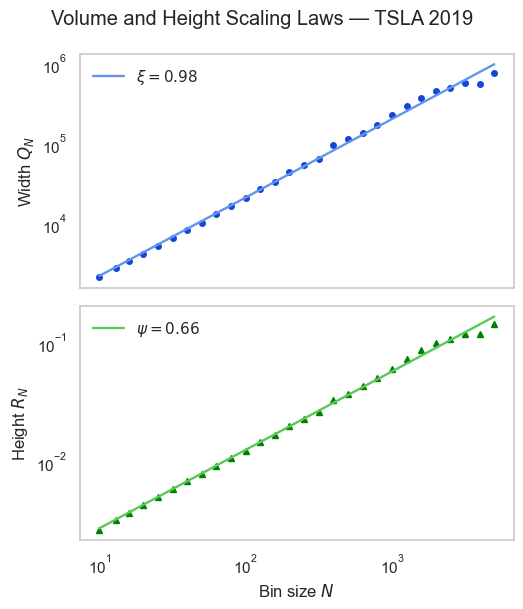

In [83]:

# ── Volume and height scaling laws ────────────────────────────────────────────
horizon_grid = np.geomspace(min(PB_HORIZONS), max(PB_HORIZONS), 300)
fig, axes = plt.subplots(2, 1, figsize=(5.4, 6.2), sharex=True)

axes[0].loglog(pb_volume_scales["horizon"], pb_volume_scales["Q_N"],
               "o", color="#1646d8", ms=4)
axes[0].loglog(horizon_grid,
               pb_volume_x_fit["prefactor"] * horizon_grid ** pb_volume_x_fit["exponent"],
               color="#6495ed", lw=1.7,
               label=f"$\\xi = {pb_volume_x_fit['exponent']:.2f}$")
axes[0].set_ylabel("Width $Q_N$")
axes[0].legend(frameon=False, loc="upper left")

axes[1].loglog(pb_volume_scales["horizon"], pb_volume_scales["R_N"],
               "^", color="green", ms=4)
axes[1].loglog(horizon_grid,
               pb_volume_y_fit["prefactor"] * horizon_grid ** pb_volume_y_fit["exponent"],
               color="#5ac85a", lw=1.7,
               label=f"$\\psi = {pb_volume_y_fit['exponent']:.2f}$")
axes[1].set_ylabel("Height $R_N$")
axes[1].set_xlabel("Bin size $N$")
axes[1].legend(frameon=False, loc="upper left")
for ax in axes:
    ax.grid(False)
fig.suptitle("Volume and Height Scaling Laws — TSLA 2019")
plt.tight_layout()
plt.show()



### 8.3 Scaling Exponents and Hurst Statistics

Patzelt and Bouchaud define a Hurst exponent from the standard deviation of
sums of $N$ successive events, not from DFA.  The left panel applies that
definition to TSLA 2019.  The right panel (cross-instrument correlation matrix)
is not estimable with a single instrument.


,estimate,regression_se
metric,,
$\xi$,0.9763,0.0116
$\psi$,0.6564,0.0061
$\xi_\varepsilon$,0.6933,0.0028
$\psi_\varepsilon$,0.7024,0.0264
$H_q$,0.6434,0.0020
$H_r$,0.5134,0.0009
$H_\varepsilon$,0.6933,0.0028
$H_\pm$,0.6204,0.0034


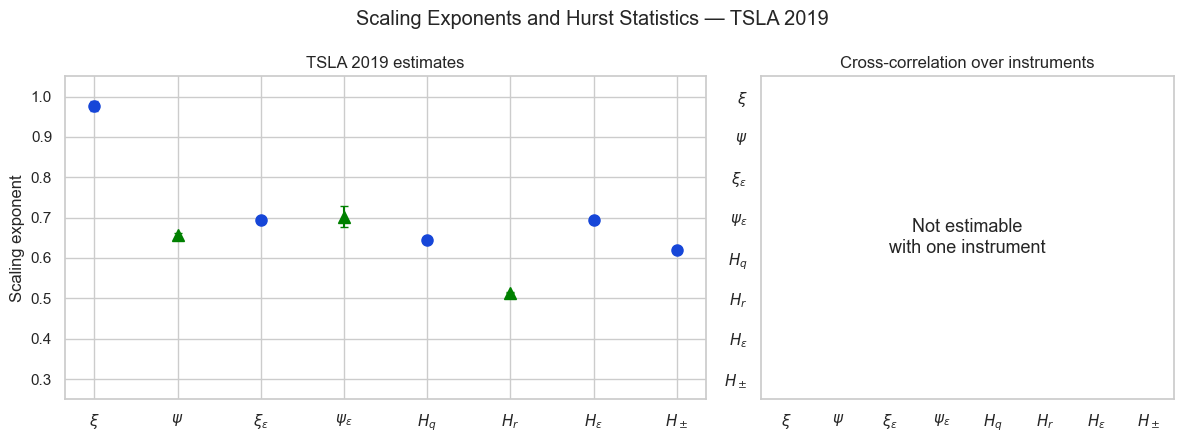

In [84]:

# ── Scaling exponents and Hurst statistics ────────────────────────────────────
pb_scale_statistics = (
    pb_windows.groupby("horizon", sort=True, observed=True)
    .agg(
        q_std=("Q", "std"),
        return_std=("impact_log", "std"),
        sign_std=("E", "std"),
        return_sign_std=("return_sign_imbalance", "std"),
    )
    .reset_index()
)
hurst_q  = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["q_std"])
hurst_r  = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["return_std"])
hurst_e  = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["sign_std"])
hurst_pm = fit_loglog_scale(pb_scale_statistics["horizon"], pb_scale_statistics["return_sign_std"])

exponent_rows = [
    ("$\\xi$",            pb_volume_x_fit),
    ("$\\psi$",           pb_volume_y_fit),
    ("$\\xi_\\varepsilon$", pb_sign_x_fit),
    ("$\\psi_\\varepsilon$", pb_sign_y_fit),
    ("$H_q$",   hurst_q),
    ("$H_r$",   hurst_r),
    ("$H_\\varepsilon$", hurst_e),
    ("$H_\\pm$", hurst_pm),
]
exponent_table = pd.DataFrame([
    {"metric": metric, "estimate": values["exponent"], "regression_se": values["stderr"]}
    for metric, values in exponent_rows
])
display(exponent_table.set_index("metric").round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.55, 1]})
x = np.arange(len(exponent_table))
colors  = ["#1646d8", "green", "#1646d8", "green", "#1646d8", "green", "#1646d8", "#1646d8"]
markers = ["o", "^", "o", "^", "o", "^", "o", "o"]
for index, row in exponent_table.iterrows():
    axes[0].errorbar(
        index, row["estimate"], yerr=row["regression_se"],
        fmt=markers[index], ms=8, color=colors[index], capsize=3,
    )
axes[0].set_xticks(x, exponent_table["metric"])
axes[0].set_ylabel("Scaling exponent")
axes[0].set_ylim(0.25, 1.05)
axes[0].set_title("TSLA 2019 estimates")

axes[1].set_xticks(x, exponent_table["metric"], rotation=0)
axes[1].set_yticks(x, exponent_table["metric"])
axes[1].set_xlim(-0.5, len(x) - 0.5)
axes[1].set_ylim(len(x) - 0.5, -0.5)
axes[1].text(
    0.5, 0.5,
    "Not estimable\nwith one instrument",
    transform=axes[1].transAxes, ha="center", va="center", fontsize=13,
)
axes[1].set_title("Cross-correlation over instruments")
axes[1].grid(False)
fig.suptitle("Scaling Exponents and Hurst Statistics — TSLA 2019")
plt.tight_layout()
plt.show()



### 8.4 Sticky Price and Visible Depth

The available LOBSTER files record only the two best occupied levels on each
side of the book. The heatmap below is therefore a faithful level-2 analogue:
red is displayed ask liquidity and blue is displayed bid liquidity before each
trade, with saturation at the daily 90th percentile. It cannot reproduce the
dense full-book field of PB (2017) without a deeper LOBSTER download.


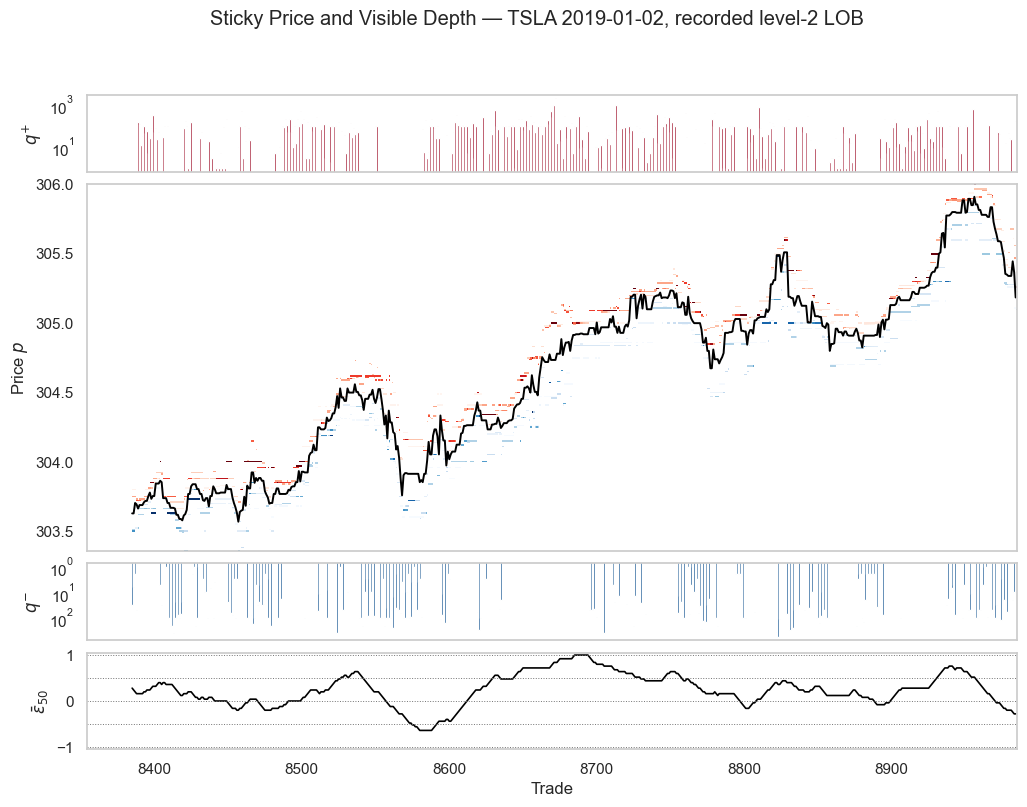

In [85]:

# ── Sticky price and visible depth ────────────────────────────────────────────
def build_recorded_depth_heatmap(
    selected: pd.DataFrame,
    tick_raw: int = 100,
) -> tuple[np.ndarray, np.ndarray, int, int, list[int]]:
    """Rasterise recorded pre-trade LOBSTER snapshots without inventing depth."""
    level_pattern = re.compile(r"(?:ask|bid)_price_(\d+)_before")
    levels = sorted({
        int(match.group(1))
        for column in selected
        if (match := level_pattern.fullmatch(column))
    })
    price_columns = [
        f"{side}_price_{level}_before"
        for side in ("ask", "bid") for level in levels
    ]
    size_columns = [
        f"{side}_size_{level}_before"
        for side in ("ask", "bid") for level in levels
    ]
    prices_raw = np.rint(selected[price_columns].to_numpy() * PRICE_SCALE).astype(int)
    sizes = selected[size_columns].to_numpy()
    positive_prices = prices_raw[sizes > 0]
    price_min_raw = int(positive_prices.min() // tick_raw * tick_raw)
    price_max_raw = int(np.ceil(positive_prices.max() / tick_raw) * tick_raw)
    price_grid_raw = np.arange(price_min_raw, price_max_raw + tick_raw, tick_raw)
    ask_depth = np.zeros((len(price_grid_raw), len(selected)))
    bid_depth = np.zeros_like(ask_depth)
    columns = np.arange(len(selected))
    for side, depth in (("ask", ask_depth), ("bid", bid_depth)):
        for level in levels:
            prices = np.rint(selected[f"{side}_price_{level}_before"] * PRICE_SCALE).astype(int)
            sizes = selected[f"{side}_size_{level}_before"].to_numpy()
            valid = sizes > 0
            rows = (prices[valid] - price_min_raw) // tick_raw
            np.add.at(depth, (rows, columns[valid]), sizes[valid])
    return ask_depth, bid_depth, price_min_raw, price_max_raw, levels


pb_plot_trades = pb_trades[
    pb_trades["seconds"].between(PB_OPEN, PB_CLOSE, inclusive="both")
].copy()
pb_plot_trades = pb_plot_trades.sort_values(["date", "first_event_row"])
pb_plot_trades["rolling_sign_50"] = (
    pb_plot_trades.groupby("date", observed=True)["trade_sign"]
    .rolling(50, min_periods=50).mean()
    .reset_index(level=0, drop=True)
)
extreme_index    = pb_plot_trades["rolling_sign_50"].abs().idxmax()
extreme_date     = pb_plot_trades.loc[extreme_index, "date"]
extreme_day      = pb_plot_trades[pb_plot_trades["date"].eq(extreme_date)].reset_index(drop=True)
extreme_position = int(extreme_day["rolling_sign_50"].abs().idxmax())
window_size  = 600
window_start = max(0, min(len(extreme_day) - window_size, extreme_position - window_size // 2))
sticky = extreme_day.iloc[window_start:window_start + window_size].reset_index(drop=True)

tick_raw = 100
ask_depth, bid_depth, price_min_raw, price_max_raw, snapshot_levels = build_recorded_depth_heatmap(
    sticky, tick_raw=tick_raw,
)
daily_depth_columns = [
    f"{side}_size_{level}_before"
    for side in ("ask", "bid") for level in snapshot_levels
]
daily_positive_depth = extreme_day[daily_depth_columns].to_numpy().ravel()
daily_positive_depth = daily_positive_depth[daily_positive_depth > 0]
depth_cap = np.quantile(daily_positive_depth, 0.90)

fig, axes = plt.subplots(
    4, 1, figsize=(12, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [0.8, 3.8, 0.8, 1.0], "hspace": 0.08},
)
trade_axis = np.arange(window_start, window_start + len(sticky))
buys  = sticky["trade_sign"].eq(1).to_numpy()
sells = sticky["trade_sign"].eq(-1).to_numpy()

axes[0].bar(trade_axis[buys], sticky.loc[buys, "size"], color="#98001b", width=1.0)
axes[0].set_yscale("log")
axes[0].set_ylabel("$q^{+}$")
axes[0].grid(False)

extent = [trade_axis[0], trade_axis[-1] + 1,
          price_min_raw / PRICE_SCALE, price_max_raw / PRICE_SCALE]
axes[1].imshow(np.ma.masked_where(ask_depth <= 0, ask_depth),
               origin="lower", aspect="auto", extent=extent,
               cmap="Reds", vmin=0, vmax=depth_cap, interpolation="nearest")
axes[1].imshow(np.ma.masked_where(bid_depth <= 0, bid_depth),
               origin="lower", aspect="auto", extent=extent,
               cmap="Blues", vmin=0, vmax=depth_cap, interpolation="nearest")
axes[1].plot(trade_axis, sticky["mid_price_before"], color="black", lw=1.4)
axes[1].set_ylabel("Price $p$")
axes[1].grid(False)

axes[2].bar(trade_axis[sells], sticky.loc[sells, "size"], color="#0a4d8c", width=1.0)
axes[2].set_yscale("log")
axes[2].invert_yaxis()
axes[2].set_ylabel("$q^{-}$")
axes[2].grid(False)

axes[3].plot(trade_axis, sticky["rolling_sign_50"], color="black", lw=1.2)
for value in [-1, -0.5, 0, 0.5, 1]:
    axes[3].axhline(value, color="0.45", lw=0.7, ls=":")
axes[3].set_ylim(-1.05, 1.05)
axes[3].set_ylabel("$\\bar{\\varepsilon}_{50}$")
axes[3].set_xlabel("Trade")
axes[3].grid(False)
fig.suptitle(f"Sticky Price and Visible Depth — TSLA {extreme_date}, recorded level-2 LOB")
plt.show()



### 8.5 Price-Change Probability and CCDF of Mean Sign

For each $N$-trade bin, the upper panel conditions the within-bin probability
of a one-trade mid-price change on the mean sign $\bar{\varepsilon}=E/N$.
The lower panel shows the complementary CDF of $|\bar{\varepsilon}|$.


C:\Users\orang\AppData\Local\Temp\ipykernel_14860\3318045883.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
C:\Users\orang\AppData\Local\Temp\ipykernel_14860\3318045883.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


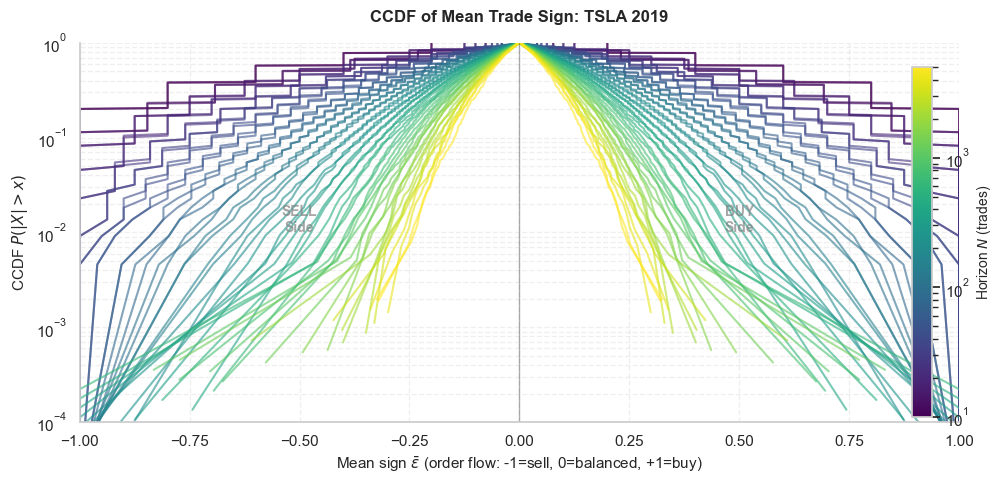

In [86]:
"""
STANDALONE CCDF PLOTS
=====================

Three different ways to visualize the CCDF of mean_sign across horizons.
Choose whichever best suits your analysis.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.cm as cm


# ════════════════════════════════════════════════════════════════════════════
# CCDF COMPUTATION (from your notebook)
# ════════════════════════════════════════════════════════════════════════════

def ccdf_lines(values: pd.Series, scale: float, max_points: int = 220):
    """
    Return positive and negative half CCDF curves.
    For mean_sign in [-1, 1], splits into positive and negative halves.
    """
    lines = []
    array = values.to_numpy(dtype=float) / scale
    
    for half in [array[array > 0], -array[array < 0]]:
        if not len(half):
            continue
        half = np.sort(half)
        keep = np.unique(np.linspace(0, len(half) - 1, min(max_points, len(half))).astype(int))
        x = half[keep]
        y = 1 - keep / len(half)
        lines.append((x, y))
    
    return lines


# ════════════════════════════════════════════════════════════════════════════
# OPTION 1: Absolute Value CCDF (Simplest)
# ════════════════════════════════════════════════════════════════════════════

def plot_ccdf_absolute(pb_windows: pd.DataFrame, pb_horizons: tuple = None,
                       title: str = "CCDF of Mean Trade Sign — TSLA 2019",
                       figsize: tuple = (8, 5)):
    """
    Plot CCDF of absolute mean_sign values.
    Shows magnitude of order-flow imbalance regardless of direction.
    
    Each horizon is a separate colored curve.
    """
    
    if pb_horizons is None:
        horizons_unique = sorted(pb_windows["horizon"].unique())
    else:
        horizons_unique = pb_horizons
    
    color_norm = LogNorm(vmin=min(horizons_unique), vmax=max(horizons_unique))
    cmap = cm.get_cmap("viridis")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for horizon, part in pb_windows.groupby("horizon", sort=True):
        color = cmap(color_norm(horizon))
        
        for x_ccdf, y_ccdf in ccdf_lines(part["mean_sign"], scale=1):
            ax.plot(x_ccdf, y_ccdf, color=color, alpha=0.6, lw=1.5, 
                   label=f"N={horizon}" if x_ccdf[0] < 0.5 else "")
    
    ax.set_yscale("log")
    ax.set_xlabel(r"Absolute mean sign $|\bar{\varepsilon}|$ (order flow magnitude)", fontsize=11)
    ax.set_ylabel(r"CCDF $P(X > x)$", fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(1e-4, 1)
    ax.grid(True, alpha=0.3, which="both", linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    
    # Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(cm.ScalarMappable(norm=color_norm, cmap=cmap),
                       cax=cbar_ax)
    cbar.set_label(r"Horizon $N$ (trades)", fontsize=10)
    
    ax.set_title(title, fontsize=12, weight="bold", pad=15)
    plt.tight_layout()
    return fig, ax


# ════════════════════════════════════════════════════════════════════════════
# OPTION 2: Symmetric CCDF (Both Buy & Sell Sides)
# ════════════════════════════════════════════════════════════════════════════

def plot_ccdf_symmetric(pb_windows: pd.DataFrame, pb_horizons: tuple = None,
                        title: str = "CCDF of Mean Trade Sign: TSLA 2019",
                        figsize: tuple = (10, 5)):
    """
    Plot CCDF with both sell-side (negative) and buy-side (positive) visible.
    
    Mirrors the positive half to negative side for symmetric display.
    Makes buy/sell asymmetries clear.
    """
    
    if pb_horizons is None:
        horizons_unique = sorted(pb_windows["horizon"].unique())
    else:
        horizons_unique = pb_horizons
    
    color_norm = LogNorm(vmin=min(horizons_unique), vmax=max(horizons_unique))
    cmap = cm.get_cmap("viridis")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for horizon, part in pb_windows.groupby("horizon", sort=True):
        color = cmap(color_norm(horizon))
        
        for x_ccdf, y_ccdf in ccdf_lines(part["mean_sign"], scale=1):
            # Plot positive half (buy side)
            ax.plot(x_ccdf, y_ccdf, color=color, alpha=0.6, lw=1.5)
            # Mirror to negative side (sell side)
            ax.plot(-x_ccdf, y_ccdf, color=color, alpha=0.6, lw=1.5)
    
    # Visual annotations
    ax.axvline(0, color="black", linestyle="-", alpha=0.3, linewidth=1)
    ax.text(-0.5, 0.5, "SELL\nSide", transform=ax.get_xaxis_transform(),
           ha="center", fontsize=10, color="gray", alpha=0.7, weight="bold")
    ax.text(0.5, 0.5, "BUY\nSide", transform=ax.get_xaxis_transform(),
           ha="center", fontsize=10, color="gray", alpha=0.7, weight="bold")
    
    ax.set_yscale("log")
    ax.set_xlabel(r"Mean sign $\bar{\varepsilon}$ (order flow: -1=sell, 0=balanced, +1=buy)", 
                 fontsize=11)
    ax.set_ylabel(r"CCDF $P(|X| > x)$", fontsize=11)
    ax.set_xlim(-1, 1)
    ax.set_ylim(1e-4, 1)
    ax.grid(True, alpha=0.3, which="both", linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    
    # Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(cm.ScalarMappable(norm=color_norm, cmap=cmap),
                       cax=cbar_ax)
    cbar.set_label(r"Horizon $N$ (trades)", fontsize=10)
    
    ax.set_title(title, fontsize=12, weight="bold", pad=15)
    plt.tight_layout()
    return fig, ax


# ════════════════════════════════════════════════════════════════════════════
# OPTION 3: Separate Buy & Sell CCDFs (Side-by-Side)
# ════════════════════════════════════════════════════════════════════════════

def plot_ccdf_buy_sell_separate(pb_windows: pd.DataFrame, pb_horizons: tuple = None,
                                title: str = "CCDF: Buy vs Sell Order Flow — TSLA 2019",
                                figsize: tuple = (14, 5)):
    """
    Plot CCDF separately for buy-side and sell-side order imbalances.
    
    Left panel: Sell orders (negative mean_sign)
    Right panel: Buy orders (positive mean_sign)
    """
    
    if pb_horizons is None:
        horizons_unique = sorted(pb_windows["horizon"].unique())
    else:
        horizons_unique = pb_horizons
    
    color_norm = LogNorm(vmin=min(horizons_unique), vmax=max(horizons_unique))
    cmap = cm.get_cmap("viridis")
    
    fig, (ax_sell, ax_buy) = plt.subplots(1, 2, figsize=figsize)
    
    for horizon, part in pb_windows.groupby("horizon", sort=True):
        color = cmap(color_norm(horizon))
        
        # Split into sell (negative) and buy (positive) sides
        sell_side = part[part["mean_sign"] < 0]["mean_sign"].abs()
        buy_side = part[part["mean_sign"] > 0]["mean_sign"]
        
        # Plot sell side
        if len(sell_side) > 0:
            sell_sorted = np.sort(sell_side.values)
            ccdf_sell = 1 - np.arange(len(sell_sorted)) / len(sell_sorted)
            ax_sell.plot(sell_sorted, ccdf_sell, color=color, alpha=0.6, lw=1.5,
                        label=f"N={horizon}")
        
        # Plot buy side
        if len(buy_side) > 0:
            buy_sorted = np.sort(buy_side.values)
            ccdf_buy = 1 - np.arange(len(buy_sorted)) / len(buy_sorted)
            ax_buy.plot(buy_sorted, ccdf_buy, color=color, alpha=0.6, lw=1.5,
                       label=f"N={horizon}")
    
    # Configure both panels
    for ax, side_name in [(ax_sell, "SELL"), (ax_buy, "BUY")]:
        ax.set_yscale("log")
        ax.set_xlabel(r"Order-flow imbalance magnitude $|\bar{\varepsilon}|$", fontsize=11)
        ax.set_ylabel(r"CCDF $P(X > x)$", fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-4, 1)
        ax.grid(True, alpha=0.3, which="both", linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_title(f"{side_name}-Side Order Flow", fontsize=11, weight="bold")
    
    # Single colorbar for both
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(cm.ScalarMappable(norm=color_norm, cmap=cmap),
                       cax=cbar_ax)
    cbar.set_label(r"Horizon $N$ (trades)", fontsize=10)
    
    fig.suptitle(title, fontsize=12, weight="bold", y=1.00)
    plt.tight_layout()
    return fig, (ax_sell, ax_buy)


# ════════════════════════════════════════════════════════════════════════════
# OPTION 4: Stacked Comparison (All Horizons in One Plot)
# ════════════════════════════════════════════════════════════════════════════

def plot_ccdf_stacked(pb_windows: pd.DataFrame, pb_horizons: tuple = None,
                      title: str = "CCDF Comparison Across Horizons — TSLA 2019",
                      figsize: tuple = (10, 8)):
    """
    Create a grid of CCDF plots, one for each horizon.
    
    Good for comparing how order-flow distribution changes with window size.
    """
    
    if pb_horizons is None:
        horizons_unique = sorted(pb_windows["horizon"].unique())
    else:
        horizons_unique = pb_horizons
    
    n_horizons = len(horizons_unique)
    n_cols = 4
    n_rows = (n_horizons + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    color_norm = LogNorm(vmin=min(horizons_unique), vmax=max(horizons_unique))
    cmap = cm.get_cmap("viridis")
    
    for idx, (horizon, part) in enumerate(pb_windows.groupby("horizon", sort=True)):
        ax = axes[idx]
        color = cmap(color_norm(horizon))
        
        for x_ccdf, y_ccdf in ccdf_lines(part["mean_sign"], scale=1):
            ax.plot(x_ccdf, y_ccdf, color=color, alpha=0.8, lw=2)
            ax.plot(-x_ccdf, y_ccdf, color=color, alpha=0.8, lw=2)
        
        ax.set_yscale("log")
        ax.set_xlim(-1, 1)
        ax.set_ylim(1e-4, 1)
        ax.grid(True, alpha=0.3, which="both", linestyle="--", linewidth=0.5)
        ax.set_title(f"N={horizon}", fontsize=10, weight="bold")
        
        if idx % n_cols == 0:
            ax.set_ylabel(r"CCDF", fontsize=9)
        if idx >= (n_rows - 1) * n_cols:
            ax.set_xlabel(r"$\bar{\varepsilon}$", fontsize=9)
        
        ax.spines[["top", "right"]].set_visible(False)
    
    # Hide unused subplots
    for idx in range(n_horizons, len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle(title, fontsize=12, weight="bold", y=0.995)
    plt.tight_layout()
    return fig, axes[:n_horizons]




# Option 1: Simple absolute value CCDF (Recommended for most cases)
fig2, ax2 = plot_ccdf_symmetric(pb_windows, pb_horizons=PB_HORIZONS)
plt.show()

## 9. Conclusions - Friday

The final presentation can follow the Monday-to-Friday course outline:

1. visible type-4 LOBSTER preparation and timestamp aggregation;
2. initial order-book, spread and return diagnostics;
3. unconditional, conditional and aggregate impact;
4. finite-size scaling and Kyle's lambda;
5. publication-style bonus figures with their TSLA-only limitations stated.

The summary table below is generated from the executed estimates so that the
reported values cannot drift away from the figures.


In [87]:

final_summary = pd.Series({
    "Visible type-4 executions": int(summary["visible_executions"].sum()),
    "Timestamp-aggregated market orders": int(summary["market_orders"].sum()),
    "PB type-4/5 timestamp transactions": int(len(pb_trades)),
    "PB type-4/5 signed fills": int(pb_trades["transaction_count"].sum()),
    "Lag-1 unconditional impact R(1), cents": r1 * 100,
    "Spread-normalised lag-1 R1": r1_spread_normalised,
    "Conditional impact exponent zeta": zeta_fit,
    "Lecture FSS xi": fss_parameters["xi"],
    "Lecture FSS psi": fss_parameters["psi"],
    "Direct Kyle decay exponent": kyle_decay["lambda_exponent"],
    "PB xi (volume)": pb_volume_x_fit["exponent"],
    "PB psi (volume)": pb_volume_y_fit["exponent"],
    "PB H_q (Hurst volume)": hurst_q["exponent"],
    "PB H_r (Hurst return)": hurst_r["exponent"],
    "PB H_epsilon (Hurst sign)": hurst_e["exponent"],
}, name="TSLA 2019")
display(final_summary.to_frame().round(5))


,TSLA 2019
Visible type-4 executions,6.504032e+06
Timestamp-aggregated market orders,4.573957e+06
PB type-4/5 timestamp transactions,5.879277e+06
PB type-4/5 signed fills,8.591382e+06
"Lag-1 unconditional impact R(1), cents",1.869810e+00
Spread-normalised lag-1 R1,1.429800e-01
Conditional impact exponent zeta,6.124000e-02
Lecture FSS xi,1.081950e+00
Lecture FSS psi,6.857000e-01
Direct Kyle decay exponent,3.162600e-01
